<h1><center><font size="6">Investment Analysis of Argentinian Real Estate Market</font></center></h1>

## Problem Statement

At Inmobiliaria X, we seek to help appraisers value properties, as it is a difficult and sometimes subjective process. To do this, a Machine Learning model will be used that, given certain characteristics of the property, predicts its sale price.

A database of properties for sale will be used, published on the portal [Properati](www.properati.com.ar).

# <a id='0'>Table of Contents</a>

1. [Getting Setup](#setup1)<br>
2. [Data Exploration](#explore)<br>
    2.1 [Exploratory Data Analysis (EDA)](#explore1)<br>
    2.2 [Imputation](#explore2)<br>
    2.3 [Principal Component Analysis](#explore3)<br>
3. [Modeling](#modeling)<br>
4. [Advanced models](#admodeling)<br>
5. [Conclusions](#con)<br>

### 1. Getting Setup <a id="setup1"></a>

Import required libraries

In [1]:
#requeriments
#pandas
#numpy
#matplotlib
#seaborn
#prettytable
#statsmodels
#scikit-learn

In [2]:
import pandas as pd # data processing
import numpy as np # matrix management
import matplotlib.pyplot as plt  # visualization
import seaborn as sns # visualization with hue
import os # access to system
from prettytable import PrettyTable

<a href="#0"><font size="1">Back to contents</font></a>

### 2. Data Exploration<a id="explore"></a>

* In order to load the data bases from google drive to colab, run the next statement without the '#' symbols:

**Note: The advantage of using Jupyter notebook comes from the availability of using the jumps created in the table of contents**

* If you downloaded the dataset from [drive](https://drive.google.com/drive/folders/17wxSBYo7_j8Yy29OJPVulYlUeEl3BDWV?usp=sharing) you can run the next statement in Jupyter to create the data frame:

In [3]:
properati= pd.read_csv('data/DS_Proyecto_01_Datos_Properati.csv')

* Read the first rows from the dataset:

In [4]:
properati.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta


Now that we have the data imported into a Notebook, we can explore it. Thanks to the following [link](https://www.properati.com.ar/data/), here is metadata explaining all of the fields in the data set. 

1. start_date - Ad start date.
2. end_date - Ad end date.
3. created_on - First version, ad start date.
4. lat - Latitude.
5. lon - Longitude.
6. l1 - Administrative level 1: Country.
7. l2 - Administrative level 2: Usually region.
8. l3 - Administrative level 3: Usually town.
9. rooms - Number of rooms (Useful for Argentina).
10. bedrooms - Number of rooms (Useful for other countries).
11. bathrooms - Number of bathrooms.
12. surface_total - Total surface in m².
13. surface_covered - Covered surface in m².
14. price - Price published in the ad.
15. currency - Currency used in the ad.
16. title - Ad title.
17. description - Ad description.
18. type - Type of property (House, Department, PH, among others).
19. operation - Rent or sale.

In l2: `Capital Federal` refers to Buenos Aires City. `Bs.As. G.B.A. Zona Norte`, `Bs.As. G.B.A. Zona Sur` y `Bs.As. G.B.A. Zona Oeste` are the regions that shape the [Gran Buenos Aires](https://es.wikipedia.org/wiki/Gran_Buenos_Aires), multiple cities that surround Buenos Aires city.

Our first goal in this exercise is to build a model that predicts the price of the properties. In other words, we will use the other variables in the data frame to predict `price`.

Now we will walk through the data.

Examine the number of rows and columns.

In [5]:
properati.shape
print(f'Rows: {properati.shape[0]}')
print(f'Columns: {properati.shape[1]}')

Rows: 146660
Columns: 19


* We use `.info()` to obtain information about quantity of records per columns and type.

In [6]:
properati.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146660 entries, 0 to 146659
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       146660 non-null  object 
 1   end_date         146660 non-null  object 
 2   created_on       146660 non-null  object 
 3   lat              136735 non-null  float64
 4   lon              136701 non-null  float64
 5   l1               146660 non-null  object 
 6   l2               146660 non-null  object 
 7   l3               146660 non-null  object 
 8   rooms            146660 non-null  float64
 9   bedrooms         146660 non-null  float64
 10  bathrooms        140703 non-null  float64
 11  surface_total    126133 non-null  float64
 12  surface_covered  125046 non-null  float64
 13  price            146660 non-null  float64
 14  currency         146660 non-null  object 
 15  title            146660 non-null  object 
 16  description      146660 non-null  obje

Mostly all columns have records with object type (this means - text or multiple characters) whereas the other columns have numeric values. Adicionally the columns # 3,4,10,11 and 12 have missing values.

* We use `.isna()` and `.sum()` to calculate the number of missing values per column:

In [7]:
properati.isna().sum().sort_values(ascending=False)

surface_covered    21614
surface_total      20527
lon                 9959
lat                 9925
bathrooms           5957
start_date             0
property_type          0
description            0
title                  0
currency               0
price                  0
bedrooms               0
end_date               0
rooms                  0
l3                     0
l2                     0
l1                     0
created_on             0
operation_type         0
dtype: int64

Both surfaces have the most missing values. The next columns with more absent data are longitude y latitude. Last but not least, number of bathrooms with almost 6k values. 

* Now we look for duplicated rows:

In [8]:
properati.duplicated().value_counts()

False    144302
True       2358
dtype: int64

2358 rows are duplicates and must be deleted in order to avoid problems in visualization and model overfitting.

In [9]:
properati.drop_duplicates(inplace=True)
properati.shape
print(f'Current row count: {properati.shape[0]}')

Current row count: 144302


* Property type count:

In [10]:
translate={'Departamento':'Department','Casa':'House','Lote':'Lot','Casa de campo':'Country House','Oficina':'Office',
          'Otro':'Other','Local comercial':'Commercial','Cochera':'Garage','Depósito':'Storage area'}

for properties in translate:
    properati['property_type']=properati.property_type.apply(lambda x: translate[properties] if x==properties else x)

In [11]:
properati.property_type.value_counts()

Department       105276
House             21443
PH                14103
Lot                1308
Office              635
Other               374
Commercial          325
Country House       314
Storage area        265
Garage              259
Name: property_type, dtype: int64

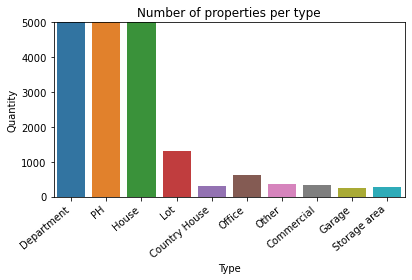

In [12]:
plot = sns.countplot(data=properati, x="property_type") 
plot.set_xticklabels(plot.get_xticklabels(), rotation=40, ha="right")
plt.title("Number of properties per type")
plt.xlabel("Type")
plt.ylabel("Quantity")
plt.tight_layout()
plt.ylim(0,5000)
plt.show()

Departament, Penthouse and House, are the top three type of properties in the data, the graphic was limited to 5000 values in order to visualize the other types of properties.

In [13]:
def analysis(df,column,low_lim,format1,pct,title):
    if low_lim ==0:
        new_df=df[column].value_counts().rename_axis(column).reset_index(name='Count')
        new_df['Percentage']=new_df.apply(lambda x: round(x['Count']*100/new_df.Count.sum(),2),axis=1)
        print(new_df)
        #new_df.to_csv(column+'_count_table.csv', index=False)
        list1=new_df[column].tolist()
        plt.figure(figsize=(7,7))
        cmap = plt.get_cmap('Spectral')
        colors = [cmap(i) for i in np.linspace(0, 1, 20)]
        plt.pie(new_df.Count,labels=list1,autopct=format1,pctdistance=pct,colors=colors)
        plt.title(title)
        #plt.savefig(title+'.png')
        plt.show()
    else:
        new_df=df[column].value_counts().rename_axis(column).reset_index(name='Count')
        new_df['Percentage']=new_df.apply(lambda x: round(x['Count']*100/new_df.Count.sum(),2),axis=1)
        print(new_df)
        top=new_df.drop(list(range(low_lim,new_df.Count.count())))
        top['Percentage']=top.apply(lambda x: round(x['Count']*100/new_df.Count.sum(),2),axis=1)
        top=top.append({column:'OTHERS','Count':(new_df.Count.sum()-top.Count.sum()),
                        'Percentage':round((100-top.Percentage.sum()),2)},ignore_index=True)
        print('\n')
        print(top)
        #new_df.to_csv(column+'_count_table.csv', index=False)
        #top.to_csv(column+'_top_count_table.csv', index=False)
        list1=top[column].tolist()
        plt.figure(figsize=(7,7))
        cmap = plt.get_cmap('Spectral')
        colors = [cmap(i) for i in np.linspace(0, 2, 20)]
        plt.pie(top.Count,labels=list1,autopct=format1,pctdistance=pct,colors=colors)
        plt.title(title)
        #plt.savefig(title+'.png')
        plt.show()

   property_type   Count  Percentage
0     Department  105276       72.96
1          House   21443       14.86
2             PH   14103        9.77
3            Lot    1308        0.91
4         Office     635        0.44
5          Other     374        0.26
6     Commercial     325        0.23
7  Country House     314        0.22
8   Storage area     265        0.18
9         Garage     259        0.18


  property_type   Count  Percentage
0    Department  105276       72.96
1         House   21443       14.86
2            PH   14103        9.77
3        OTHERS    3480        2.41


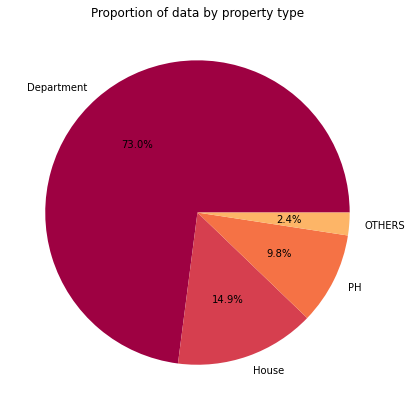

In [14]:
# The last number in the function analysis() corresponds to the index from the table in which you want to make the division
# if the number is 0 the function does not make any division.
analysis(properati,'property_type',3,'%0.1f%%',0.6,'Proportion of data by property type')

Almost 73% of all the data corresponds to deparments ads and only 2.41% represents properties different from departments, penthouses and houses.

* l3 - Country count

In [15]:
properati.l1.value_counts()

Argentina    144302
Name: l1, dtype: int64

* l2 - Region count

                         l2  Count  Percentage
0           Capital Federal  90905       63.00
1  Bs.As. G.B.A. Zona Norte  23691       16.42
2    Bs.As. G.B.A. Zona Sur  17140       11.88
3  Bs.As. G.B.A. Zona Oeste  12566        8.71


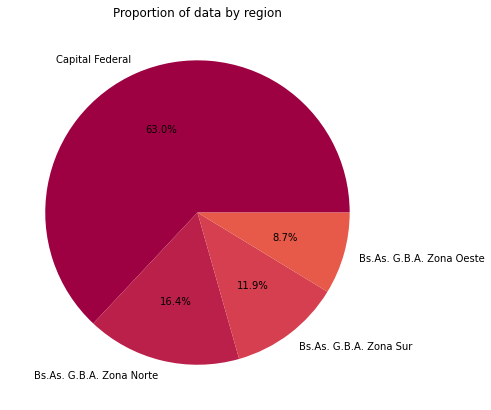

In [16]:
analysis(properati,'l2',0,'%0.1f%%',0.6,'Proportion of data by region')

Almost 63% of all the data corresponds to Capital Federal.

* l3 - Town count

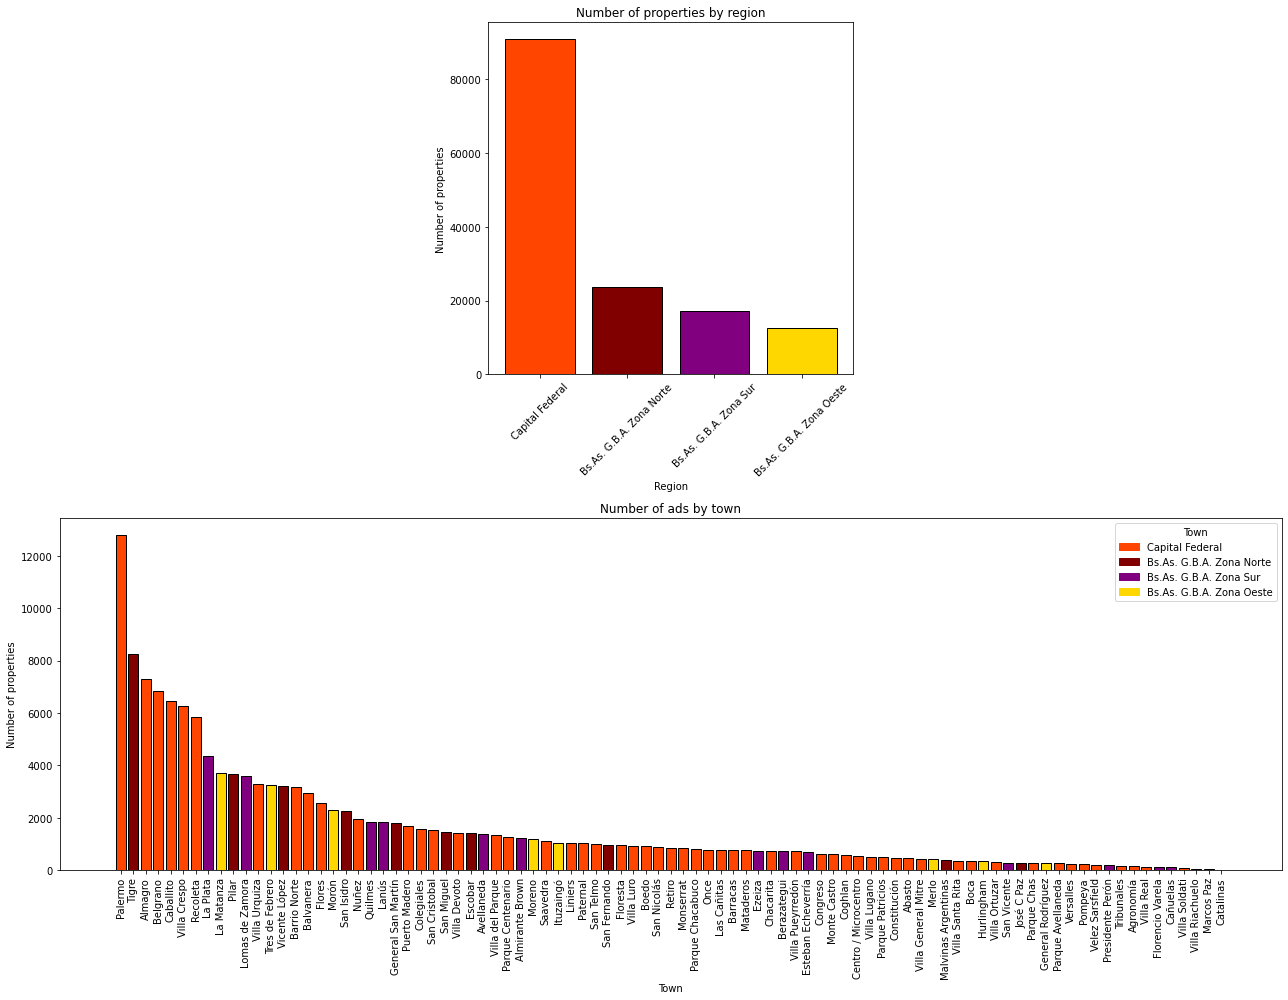

In [17]:
fig = plt.figure(figsize =(18, 14))
gs = fig.add_gridspec(2, 3)

colors = {'Capital Federal':'orangered', 'Bs.As. G.B.A. Zona Norte':'maroon', 'Bs.As. G.B.A. Zona Sur':'purple', 'Bs.As. G.B.A. Zona Oeste':'gold'} # diccionario para etiquetar por color cada ciudad visualmente en el gráfico. 

region_count = properati.l2.value_counts() # Number of ads by region
town_count = properati.l3.value_counts() # Number of ads by town

ax1 = fig.add_subplot(gs[0, 1])
x_values2 = range(len(region_count))
y_values2 = region_count 
plt.bar(x_values2, y_values2, color = colors.values(), edgecolor='black')
ax1.set_xticks(range(len(region_count)))
ax1.set_xticklabels(region_count.keys(), rotation = 45)
plt.xlabel('Region')
plt.ylabel('Number of properties')
ax1.set_title('Number of properties by region')

ax2 = fig.add_subplot(gs[1, 0:])
x_values1 = list(range(len(town_count)))
y_values1 = town_count

towns_by_region = properati.groupby(['l2', 'l3'])['l1'].count() # Ad count by 'l3'(Towns) by region

# Set town color as region color
colors_hue = []
for town in town_count.keys():
    for region, color in colors.items():
        if town in towns_by_region[region]:
            colors_hue.append(color)

plt.bar(x_values1, y_values1, color = colors_hue, edgecolor='black')
ax2.set_xticks(range(len(town_count))) # X ticks location
ax2.set_xticklabels(town_count.keys(), rotation = 90)
plt.xlabel('Town')
plt.ylabel('Number of properties')
ax2.set_title('Number of ads by town')

# Labeling
labels = region_count.keys() # Names of town
rectangles = [plt.Rectangle((0,0),1,1, color=colors[l]) for l in labels] # Rectangle list 
plt.legend(rectangles, labels, title="Town") # Classification legend

plt.tight_layout()

#plt.savefig('bar_plot_by_town.png', bbox_inches='tight')
plt.show()

There are 89 towns and the towns with more data are Palermo (9%), Tigre(6%), Almagro (5%) and Belgrano (5%), this four cities sum up to 25% of the records. 

Analyzing by colors Capital federal is the region with the most quantity of ads and the towns with the most quantity of ads are located in Capital Federal, except by Tigre's town.

* operation_type Count

In [18]:
properati.operation_type.value_counts()

Venta    144302
Name: operation_type, dtype: int64

* Created on and start date

In [19]:
(properati.created_on == properati.start_date).sum()

144302

All the ads are from Argentina, are in sale and the currency type is USD, so we can drop 'l1', 'operation_type' and 'currency' columns. Also we already have the information about town and region so having missing lat and lon is not a big problem. 'Start date' is the same as 'created on' so we are going to remove 'created on'. Finally, 'title' and 'description' do not have a useful information to enhance the machine learning model.

In [20]:
properati.drop(columns=['l1','operation_type','lon','lat','currency','created_on','title','description'], inplace=True)
properati.shape

(144302, 11)

<a href="#0"><font size="1">Back to contents</font></a>

### 2.1. Exploratory Data Analysis (EDA)<a id="explore1"></a>

In [21]:
three = properati[(properati.property_type.isin(['Department','House','PH']))].reset_index(drop=True).copy()
three.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140822 entries, 0 to 140821
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       140822 non-null  object 
 1   end_date         140822 non-null  object 
 2   l2               140822 non-null  object 
 3   l3               140822 non-null  object 
 4   rooms            140822 non-null  float64
 5   bedrooms         140822 non-null  float64
 6   bathrooms        136640 non-null  float64
 7   surface_total    122453 non-null  float64
 8   surface_covered  122176 non-null  float64
 9   price            140822 non-null  float64
 10  property_type    140822 non-null  object 
dtypes: float64(6), object(5)
memory usage: 11.8+ MB


By dividing the dataset in three types of properties and by Capital Federal (region with the most ads) we ended up with a dataset with 89874 rows and 16 columns. 

* Correlation between features

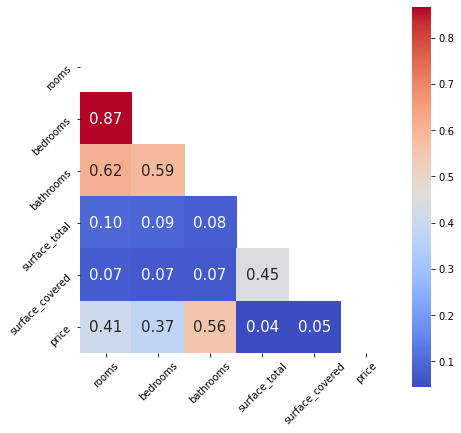

In [22]:
corr=three.corr()
plt.figure(figsize=(7,7))
mask=np.zeros_like(corr)
mask[np.triu_indices_from(mask)]=True
sns.heatmap(corr,cbar=True,square=True,annot=True,mask=mask,fmt='.2f',annot_kws={'size':15},
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

There is a high correlation between rooms-bedrooms.And our feature "price" to predict is stronger correlated to bathrooms.

* Missing values

The next analysis, we generate frequency tables to see whether there are any correlation between features and the data missing.

In [23]:
three.isna().sum().sort_values(ascending=False)

surface_covered    18646
surface_total      18369
bathrooms           4182
start_date             0
end_date               0
l2                     0
l3                     0
rooms                  0
bedrooms               0
price                  0
property_type          0
dtype: int64

In [24]:
def mva(dataframe, col_wmiss, col_analize, vtype, bins=20):
    '''
    mva(missing values analysis) Compare values from one specific column to the other columns.
    '''
    if vtype == 'discrete':
        df_new = dataframe[col_wmiss].isnull().groupby([dataframe[col_analize]]).sum().astype(int).reset_index(name='count')
        return df_new
    elif vtype == 'continuous':
        df_new = dataframe.copy()
        df_new['gap'] = pd.cut(df_new[col_analize], bins = bins)
        df_new2 = df_new[col_wmiss].isnull().groupby([df_new['gap']]).sum().astype(int).reset_index(name='count')
        df_new2['frequency'] = df_new2['count']/df_new.groupby([df_new['gap']]).count()[col_analize].values
        df_new2['center_bin'] = df_new2['gap'].apply(lambda x: x.mid)
        return df_new2
    else:
        print('Try again')

In [25]:
dic={'discrete':['rooms', 'bedrooms','bathrooms','property_type'], 'continuous':['surface_total','surface_covered','price']}

In [26]:
def plot_missing(df,column_,dictionary,bins=20):
    i = 0
    plt.figure(figsize=(15,20))
    for kind in dic:
        for column in dic[kind]:
            if (kind == 'continuous') & (column_ != column):
                ax = plt.subplot(4,3,i+1)
                data = mva(three, column_, column, kind,bins)
                plt.scatter(data['center_bin'], data['frequency'],c='orangered')
                plt.xlabel(f'Bin center {column}')
                plt.ylabel('Frequency of missing values')
                i+=1
            else:
                if column_ != column:
                    ax = plt.subplot(4,3,i+1)
                    data = mva(three, column_, column, kind)
                    plt.bar(data[column], data['count'],color='orangered')
                    plt.xlabel(f'{column}')
                    plt.ylabel('Value missing count')
                    i+=1
    plt.tight_layout()
    plt.show()

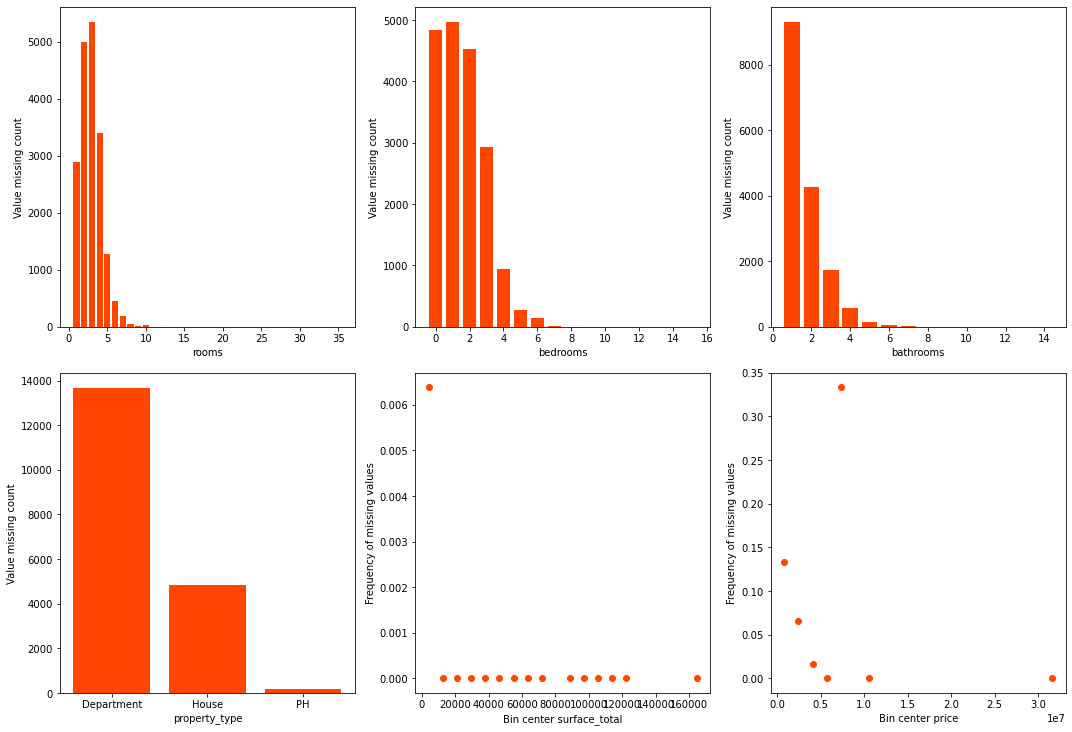

In [27]:
plot_missing(three,'surface_covered',dic)

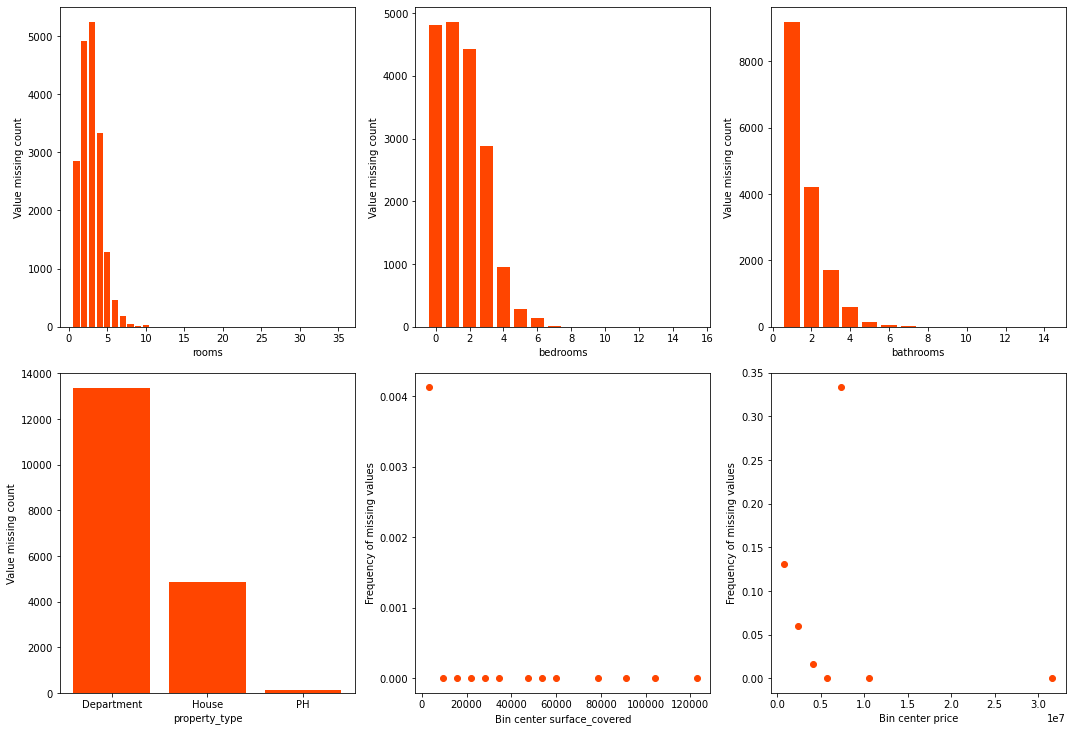

In [28]:
plot_missing(three,'surface_total',dic)

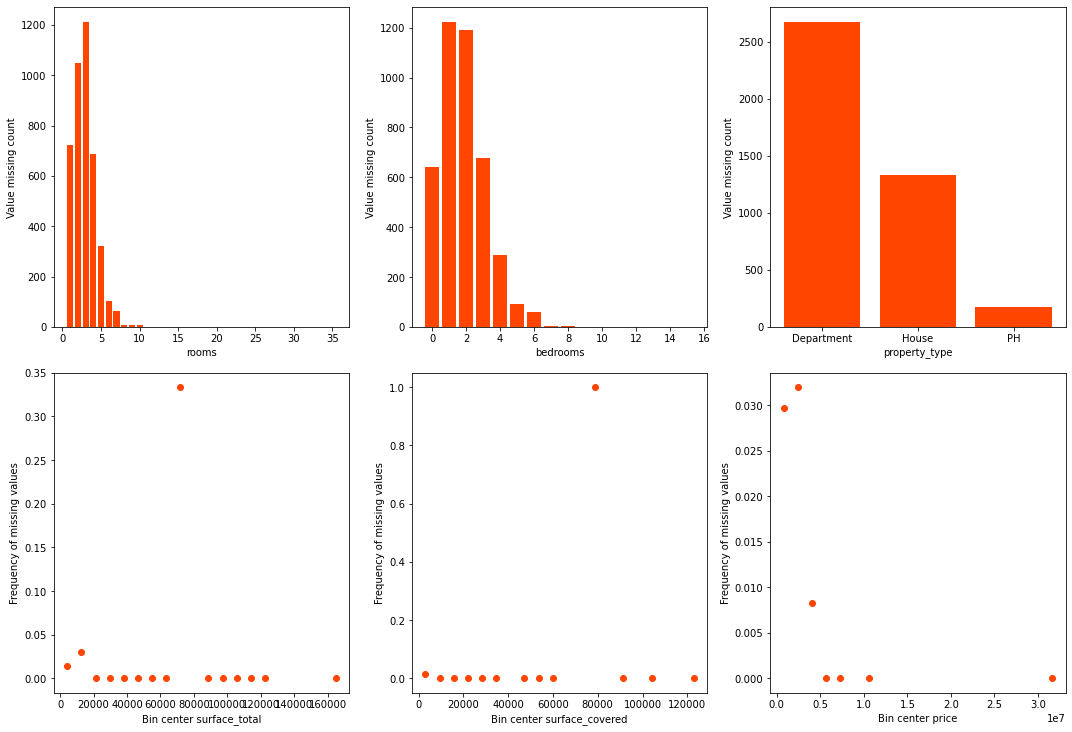

In [29]:
plot_missing(three,'bathrooms',dic)

The missing values in covered surface column are more common for departments with low numbers of rooms, bathrooms, lower price and lower total surface. The same analysis applies for the total surface column and the number of bathrooms.

<a href="#0"><font size="1">Back to contents</font></a>

### 2.2. Imputation<a id="explore2"></a>

* **Imputation of missing data**

We are going to use KNN imputer because the missing values are concentrated in the data with similar low values in their features and this imputation technique uses the nearest values in order to input the missing data.

In [30]:
from sklearn.impute import KNNImputer

In [31]:
imputer = KNNImputer(n_neighbors=4)

We are going to use only the numeric columns for the imputation:

In [32]:
num_cols = [col for col in three.columns if three[col].dtypes != 'O' and col not in "Id"]

In [33]:
num_cols

['rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price']

In [34]:
num = three[['bathrooms', 'surface_total', 'surface_covered', 'price']]

In [35]:
%%time
imp = imputer.fit_transform(num)

Wall time: 2min 44s


In [36]:
imp_three = three.copy()

In [37]:
imp_three[['bathrooms', 'surface_total', 'surface_covered', 'price']] = imp

In [38]:
imp_three.isna().sum()

start_date         0
end_date           0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
price              0
property_type      0
dtype: int64

In [39]:
imp_three

,start_date,end_date,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,2019-10-17,2019-12-23,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,Department
1,2019-10-17,2019-11-21,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,PH
2,2019-10-17,2019-11-01,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,PH
3,2019-10-17,2019-12-23,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,PH
4,2019-10-17,2020-03-11,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,PH
...,...,...,...,...,...,...,...,...,...,...,...
140817,2019-07-31,2019-08-13,Bs.As. G.B.A. Zona Sur,Berazategui,2.0,1.0,1.0,54.0,48.0,165000.0,Department
140818,2019-07-31,2019-08-14,Bs.As. G.B.A. Zona Norte,Pilar,4.0,3.0,2.0,164.0,90.0,130000.0,Department
140819,2019-07-31,2019-08-14,Bs.As. G.B.A. Zona Norte,Pilar,1.0,1.0,1.0,50.0,35.0,73000.0,Department
140820,2019-07-31,2019-08-14,Bs.As. G.B.A. Zona Norte,Pilar,2.0,1.0,1.0,38.0,38.0,68000.0,Department


* **Outliers management:**

In statistics, an outlier is a data point that differs significantly from other observations. An outlier may be due to variability in the measurement or it may indicate experimental error.

Ocasionally the outliers are subjectives, and there are many numeric methods to classify them. The simplest method is **Tukey's range test** represented by the next equations:

`q < Q1 - 1.5 * IQR` or `q > Q3 + 1.5 * IQR`

Where **q** is the outlier, **Q1** is the first quartile (Is the median of the lower half of the data set. This means that about 25% of the numbers in the data set lie below Q1 and about 75% lie above Q1), **Q3** is the third quartile (75%) and **IQR** is the interquartile range `IQR = Q3 - Q1`.

Another method to classify the outliers is using the *Medcouple* (MC), this value identifies the skewness of one variable distribution [Reference paper](https://www.researchgate.net/publication/245023815_Outlier_detection_for_skewed_data).

If MC is greater than 0, we use the next equations to classify outliers:
`q < Q1 - 1.5 * IQR * exp(-4*MC)` or `q > Q3 + 1.5 * IQR * exp(3*MC)`.
If MC is lower than 0, we use the next equations to classify outliers:
`q < Q1 - 1.5 * IQR * exp(-3*MC)` or `q > Q3 + 1.5 * IQR * exp(4*MC)`.

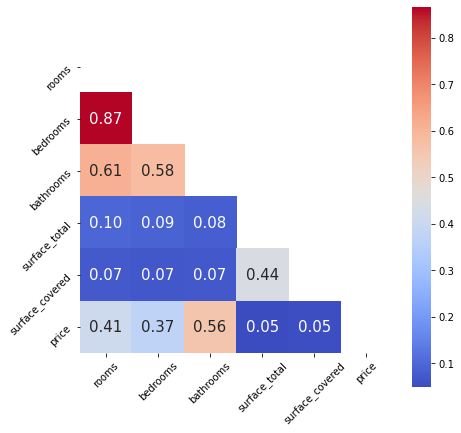

In [40]:
corr1 = imp_three.corr()
plt.figure(figsize=(7,7))
mask = np.zeros_like(corr1)
mask[np.triu_indices_from(mask)]=True
sns.heatmap(corr1,cbar=True,square=True,annot=True,mask=mask,fmt='.2f',annot_kws={'size':15},
            xticklabels=corr1.columns,
            yticklabels=corr1.columns,
            cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [41]:
from statsmodels.stats.stattools import medcouple
import math

Now we created 6 functions that will help us analyze the outlier removal using three different methods: Tukey's test, plus 3std & minus 3std and medcouple.

In [42]:
#The next function calculate the limits supossing the values trusted as 1.5 times the interquartile range 
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.25)
    quartile3 = dataframe[variable].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

#The next function calculate the limits supossing the values trusted as 3 times the standar deviation
def outlier_thresholds_std(dataframe, variable):
    up_limit = dataframe[variable].mean() + 3 * dataframe[variable].std()
    low_limit = dataframe[variable].mean() - 3 * dataframe[variable].std()
    return low_limit, up_limit

#The next function calculate the limits supossing the values trusted as 1.5 times the interquartile range multiply by a medcouple corrector
def outlier_thresholds_med(dataframe, variable):
    MC=medcouple(np.random.choice(dataframe[variable].to_numpy(),size=9999))
    quartile1 = dataframe[variable].quantile(0.25)
    quartile3 = dataframe[variable].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    low_limit = quartile1-1.5*math.exp(-4*MC)*(interquantile_range)
    up_limit = quartile3+1.5*math.exp(3*MC)*(interquantile_range)
    return low_limit, up_limit

#The next function filter the dataset according the limits established in the functions above
def has_outliers(dataframe, num_col_names, plot=False):
    variable_names = []
    new_df = dataframe.copy()
    for col in num_col_names:
        low_limit, up_limit = outlier_thresholds(dataframe, col)
        if dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].any(axis=None):
            number_of_outliers = dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].shape[0]
            print("lower limit: {:.2f} - upper limit: {:.2f}".format(low_limit, up_limit))
            print("Outliers in", col.upper(), ":", number_of_outliers)
            variable_names.append(col)
        if col != 'price': #Filter over all feutures less price
            new_df = new_df[(new_df[col] <= up_limit) & (new_df[col] >= low_limit)]
        if plot:
                sns.boxplot(x=new_df[col])
                plt.show()
    print("Remaining rows: " + str(new_df.shape[0]))
    return new_df

def has_outliers_std(dataframe, num_col_names, plot=False):
    variable_names = []
    new_df = dataframe.copy()
    for col in num_col_names:
        low_limit, up_limit = outlier_thresholds_std(dataframe, col)
        if dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].any(axis=None):
            number_of_outliers = dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].shape[0]
            print("lower limit: {:.2f} - upper limit: {:.2f}".format(low_limit, up_limit))
            print("Outliers in",col.upper(), ":", number_of_outliers)
            variable_names.append(col)
        if col != 'price':#Filter over all feutures less price
            new_df = new_df[(new_df[col] <= up_limit) & (new_df[col] >= low_limit)]
        if plot:
                sns.boxplot(x=new_df[col])
                plt.show()
    print("Remaining rows: " + str(new_df.shape[0]))
    return new_df
    
def has_outliers_med(dataframe, num_col_names, plot=False):
    variable_names = []
    new_df = dataframe.copy()
    for col in num_col_names:
        low_limit, up_limit = outlier_thresholds_med(dataframe, col)
        if dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].any(axis=None):
            number_of_outliers = dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].shape[0]
            print("lower limit: {:.2f} - upper limit: {:.2f}".format(low_limit, up_limit))
            print("Outliers in", col.upper(), ":", number_of_outliers)
            variable_names.append(col)
        if col != 'price':
            new_df = new_df[(new_df[col] <= up_limit) & (new_df[col] >= low_limit)]
        if plot:
                sns.boxplot(x=new_df[col])
                plt.show()
    print("Remaining rows: " + str(new_df.shape[0]))
    return new_df

Outlier count with Tukey's test

lower limit: -1.00 - upper limit: 7.00
Outliers in ROOMS : 1376


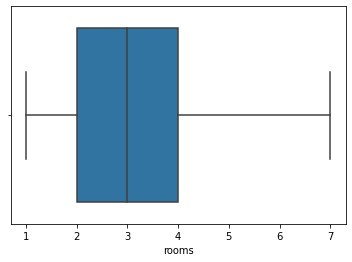

lower limit: -2.00 - upper limit: 6.00
Outliers in BEDROOMS : 395


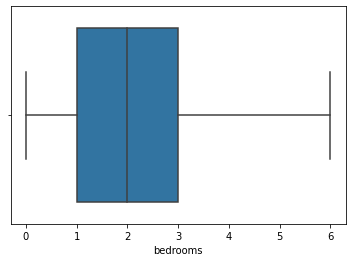

lower limit: -0.50 - upper limit: 3.50
Outliers in BATHROOMS : 5485


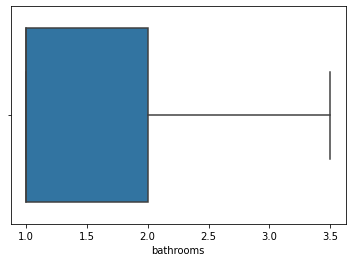

lower limit: -80.00 - upper limit: 272.00
Outliers in SURFACE_TOTAL : 14780


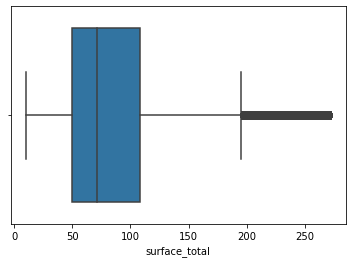

lower limit: -44.50 - upper limit: 199.50
Outliers in SURFACE_COVERED : 11059


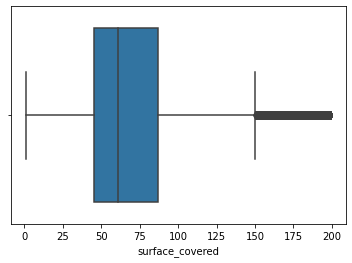

lower limit: -115571.00 - upper limit: 491285.00
Outliers in PRICE : 10503


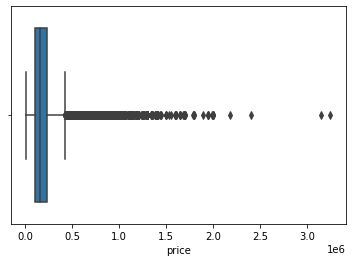

Remaining rows: 120702

Outlier count with plus and minus 3 std

lower limit: -1.09 - upper limit: 7.29
Outliers in ROOMS : 1376
lower limit: -1.39 - upper limit: 5.40
Outliers in BEDROOMS : 1100
lower limit: -1.05 - upper limit: 4.24
Outliers in BATHROOMS : 1581
lower limit: -3898.95 - upper limit: 4265.30
Outliers in SURFACE_TOTAL : 380
lower limit: -2497.25 - upper limit: 2720.57
Outliers in SURFACE_COVERED : 208
lower limit: -620709.69 - upper limit: 1095138.60
Outliers in PRICE : 2460
Remaining rows: 137389

Outlier count with med couple

lower limit: -1.00 - upper limit: 7.00
Outliers in ROOMS : 1376
lower limit: -2.00 - upper limit: 6.00
Outliers in BEDROOMS : 395
lower limit: 33.02 - upper limit: 705.29
Outliers in SURFACE_TOTAL : 8915
lower limit: 28.53 - upper limit: 411.79
Outliers in SURFACE_COVERED : 4061
lower limit: 54667.68 - upper limit: 903677.16
Outliers in PRICE : 5457
Remaining rows: 129805


In [43]:
print("Outlier count with Tukey's test\n")
df_tukey = has_outliers(imp_three, num_cols, plot=True)
print('')
print("Outlier count with plus and minus 3 std\n")
df_std = has_outliers_std(imp_three, num_cols)
print('')
print("Outlier count with med couple\n")
df_med = has_outliers_med(imp_three, num_cols)

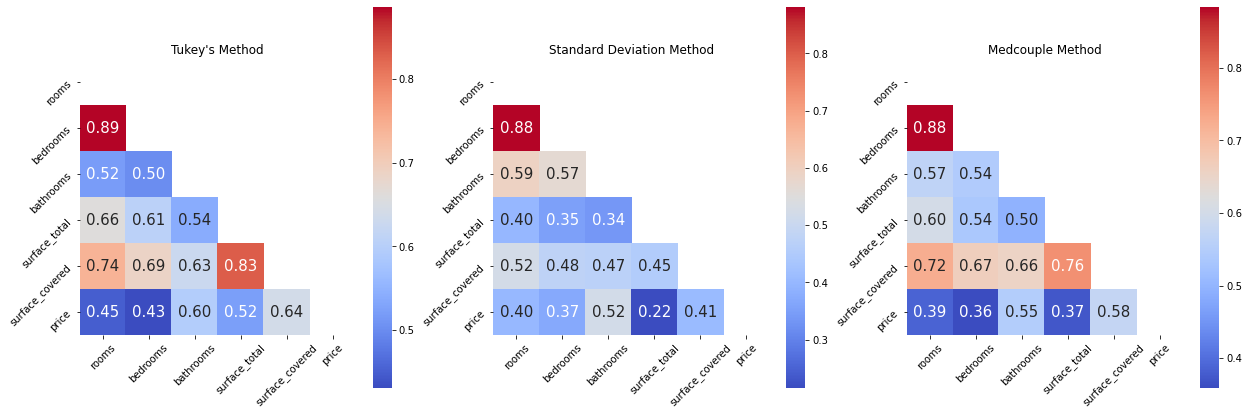

In [44]:
methods = {"Tukey's Method":df_tukey, "Standard Deviation Method":df_std, "Medcouple Method":df_med}
plt.figure(figsize=(21,7))
for i, method in enumerate(methods):
    plt.subplot(1,3, i+1)
    corr1=methods[method].corr()
    mask=np.zeros_like(corr1)
    mask[np.triu_indices_from(mask)]=True
    sns.heatmap(corr1,cbar=True,square=True,annot=True,mask=mask,fmt='.2f',annot_kws={'size':15},cmap='coolwarm')
    plt.title(method)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

plt.show()

Analyzing the above graphics we are going to select the dataframe resulting of applying the Tukey's test, because of this method created a dataframe with higher correlation of features to the target *price*. 

The only downsize is that the selected method is the one who eliminate the most rows.

In [45]:
df_tukey.shape 

(120702, 11)

* **Encoding**

Now we are going to use the categorical columns so we will use encoding in order to transform categorical to numerical.

In [46]:
cat_cols = [col for col in three.columns if three[col].dtypes == 'O' and col not in "Id"][2::]
cat_cols

['l2', 'l3', 'property_type']

In [47]:
df_dum = pd.get_dummies(df_tukey, columns = cat_cols)

In [48]:
df_dum.head()

,start_date,end_date,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,l2_Bs.As. G.B.A. Zona Norte,l2_Bs.As. G.B.A. Zona Oeste,...,l3_Villa Pueyrredón,l3_Villa Real,l3_Villa Riachuelo,l3_Villa Santa Rita,l3_Villa Soldati,l3_Villa Urquiza,l3_Villa del Parque,property_type_Department,property_type_House,property_type_PH
1,2019-10-17,2019-11-21,2.0,1.0,2.0,70.0,58.0,159000.0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2019-10-17,2019-11-01,2.0,1.0,1.0,45.0,45.0,125000.0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2019-10-17,2019-12-23,2.0,1.0,1.0,85.0,50.0,295000.0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2019-10-17,2020-03-11,2.0,1.0,1.0,50.0,35.0,40000.0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,2019-10-17,2019-11-01,2.0,1.0,1.0,56.0,56.0,150000.0,0,0,...,0,0,0,0,0,0,0,0,0,1


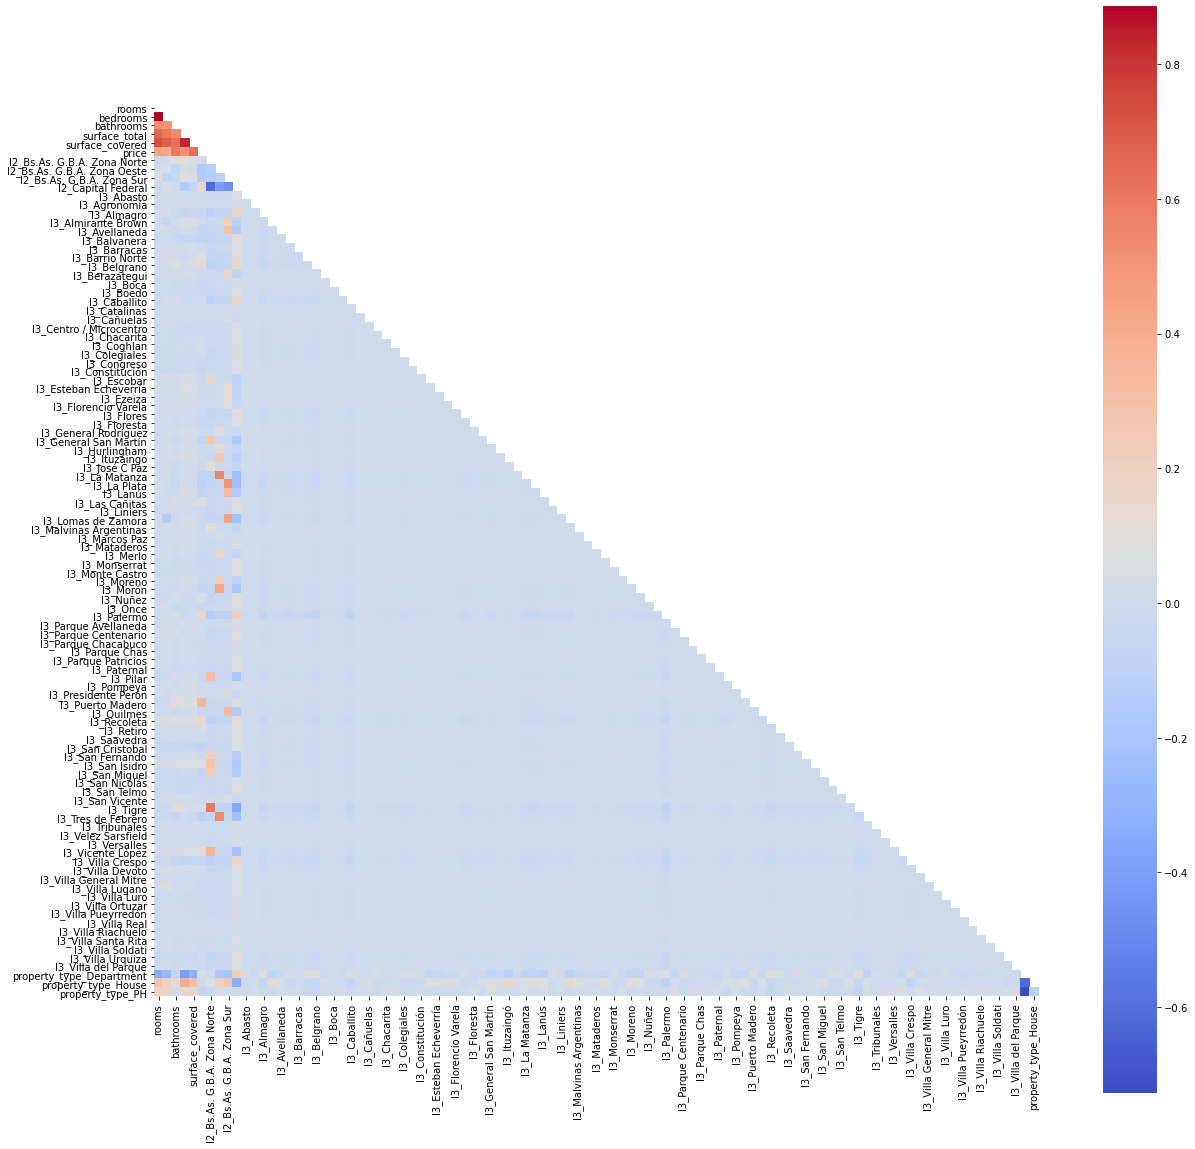

In [49]:
plt.figure(figsize=(20,20))
corr1=df_dum.corr()
mask=np.zeros_like(corr1)
mask[np.triu_indices_from(mask)]=True
sns.heatmap(corr1,cbar=True,square=True,mask=mask,cmap='coolwarm')

plt.show()

This heatmap is very hard to analyze some correlation between price and others features, so in the next visualization we can see better its correlation.

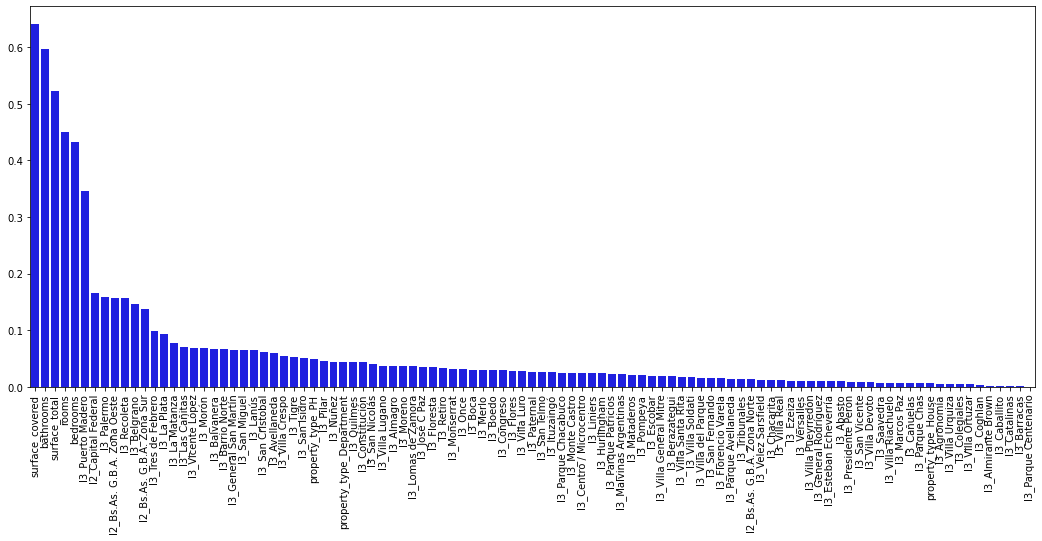

In [50]:
corr=df_dum.corr()['price'].abs().sort_values(ascending=False)

plt.figure(figsize=(18,7))
sns.barplot(x=corr.index[1:], y=corr.values[1:], color='b')
plt.xticks(rotation=90)
plt.show()

We can see in the heat map and in the bar plot that the features more correlated with price are the surface covered, bathrooms and surface total. The other features that were obtained using hot encoding or dummies do not have a great correlation to price.

<a href="#0"><font size="1">Back to contents</font></a>

### 2.3. Principal Component Analysis<a id="explore3"></a>

* **Dimensionality reduction**

We are applying dimensionality reduction to figure out the least amount of features that represents our data. This would help to the training step reducing the computional complexity.

In [51]:
pre_pros = df_dum.drop(columns=['start_date','end_date','price'])

* Feature Scaling

It is important to notice that the StandardScaler method affects the dummies variables so we are only applying that transformation to the numeric columns with the exception of the target column: price.

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
pre_pros_std = pre_pros.copy()
pre_pros_std[num_cols[:-1]] = StandardScaler().fit_transform(pre_pros[num_cols[:-1]])

We are going to calculate the Principal Component Analysis or Eigen vector values with the objective of reduce the number of features needed to represent the current data.

In [54]:
mean_vec = np.mean(pre_pros_std, axis=0)
cov_mat = (pre_pros_std - mean_vec).T.dot((pre_pros_std - mean_vec)) / (pre_pros_std.shape[0]-1)
# print('Covariance matrix \n%s' %cov_mat)

In [55]:
# print('NumPy covariance matrix: \n%s' %np.cov(X_std.T))

Eigen decomposition of the covariance matrix

In [56]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

# print('Eigenvectors \n%s' %eig_vecs)
# print('\nEigenvalues \n%s' %eig_vals)

In [57]:
# Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues
# print('Eigenvalues in descending order:')
# for i in eig_pairs:
    #print(i[0])

In [58]:
tot = sum(eig_vals)
var_exp = [(i / tot)*100 for i in sorted(eig_vals, reverse=True)]

In [59]:
len(var_exp)

101

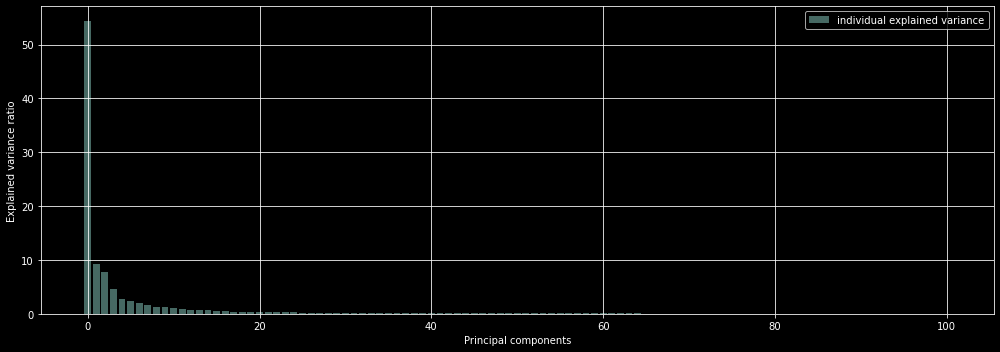

In [60]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(14, 5))

    plt.bar(range(len(var_exp)), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    #plt.xlim(0,65,1)
    plt.grid()
    plt.tight_layout()

Number of components needed to reach 99.9% of the data variance:84


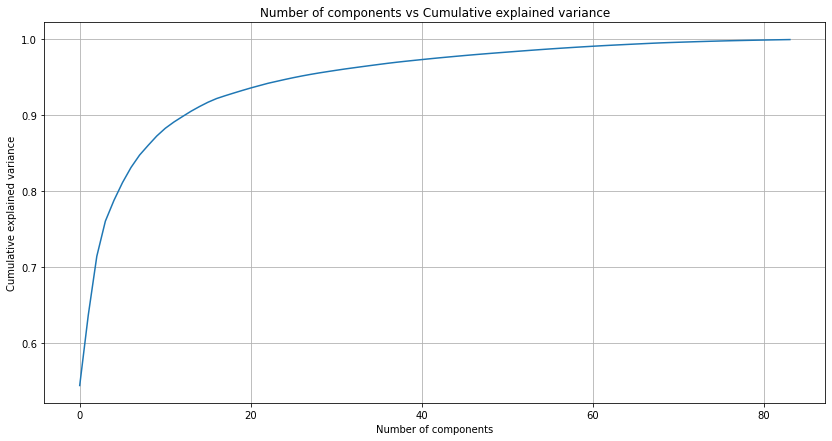

In [61]:
from sklearn.decomposition import PCA
cumulative_var = 0.999
pca = PCA(cumulative_var).fit(pre_pros_std)
print("Number of components needed to reach {0}% of the data variance:{1}".format(cumulative_var*100,pca.n_components_))
plt.figure(figsize=(14,7))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlim(0,100,1)
plt.title('Number of components vs Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()

In [62]:
pca = PCA(0.95).fit(pre_pros_std)
print("Count of PCA features:",len(pca.explained_variance_ratio_))
print("Percentage reached", round(sum(pca.explained_variance_ratio_)*100,2))
#print(pca.singular_values_)

Count of PCA features: 27
Percentage reached 95.13


The calculations and graphics done before, tell us that with only 27 PCA features we can represent 95% of the data provided by the 101 features.

In [63]:
X_pca = pca.fit_transform(pre_pros_std)

In [64]:
X_pca.shape

(120702, 27)

In [65]:
col_pca = ['pc_{0}'.format(i+1) for i in range(X_pca.shape[1])]

In [66]:
print(col_pca)

['pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_6', 'pc_7', 'pc_8', 'pc_9', 'pc_10', 'pc_11', 'pc_12', 'pc_13', 'pc_14', 'pc_15', 'pc_16', 'pc_17', 'pc_18', 'pc_19', 'pc_20', 'pc_21', 'pc_22', 'pc_23', 'pc_24', 'pc_25', 'pc_26', 'pc_27']


In [67]:
df_corr = pd.DataFrame(X_pca, columns = col_pca)
df_corr['price'] = df_dum.reset_index().price

<Figure size 1080x504 with 0 Axes>

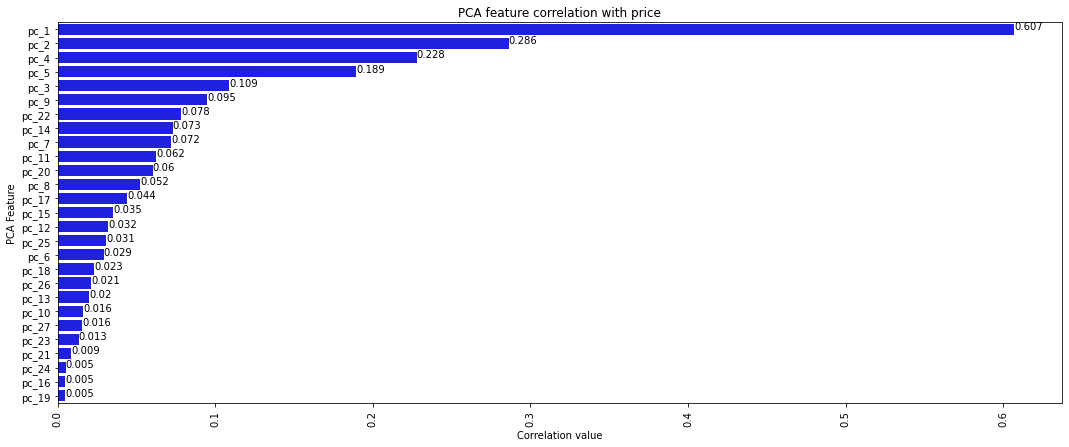

In [68]:
plt.figure(figsize=(15,7))
corr=df_corr.corr()['price'].abs().sort_values(ascending=False)

plt.figure(figsize=(18,7))

sns.barplot(y=corr.index[1:], x=corr.values[1:], color='b', orient='h')
for index, correlation in enumerate(corr[1:]): 
    plt.text(correlation, index, str(round(correlation, 3)))
    
plt.xticks(rotation=90)
plt.title("PCA feature correlation with price")
plt.xlabel("Correlation value")
plt.ylabel("PCA Feature")
plt.show()

Organizing the PCA features using their correlation with price we found that the behaviour of the graph it is different than the one done using the feature before PCA transformation. For example, the surface covered has a correlation of 0.65 and the pc_1 has 0.601; bathrooms on the other hand, has a correlation of 0.6 and pc_2 has 0.268. The gap between the two first highest correlated features increase substantially. 

We are going to apply logarithm to the price in order to manage the data more easily and try to reduce the magnitude of price. 

In [69]:
df_corr['log_price'] = np.log(df_corr['price'])

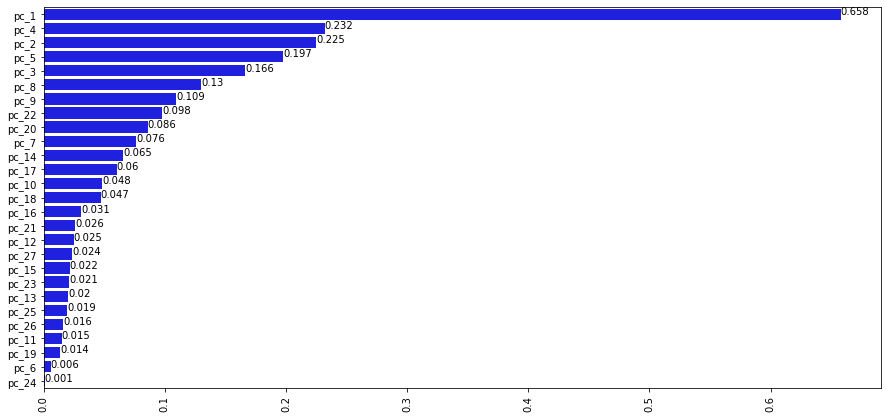

In [70]:
corr=df_corr.corr()['log_price'].abs().sort_values(ascending=False)

plt.figure(figsize=(15,7))
sns.barplot(y=corr.index[2:], x=corr.values[2:], color='b', orient='h')
for index, correlation in enumerate(corr[2:]): 
    plt.text(correlation, index, str(round(correlation, 3)))
plt.xticks(rotation=90)
plt.show()

The behaviour of the graph changed a little bit, increasing the value of the correlation of the first feature and reducing it for the second one. The others features changed a little aswell.   

In [71]:
X = df_corr[['pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_7', 'pc_8', 'pc_9', 'pc_14', 'pc_17','pc_20', 'pc_22']]
y = df_corr.price
y_log =df_corr.log_price

<a href="#0"><font size="1">Back to contents</font></a>

### 3. Modeling<a id="modeling"></a>

* The best previous model - Used as a benchmark for the advance modeling (We are going to use the same boundaries)

In [72]:
data_ml = properati[(properati.l2 == 'Capital Federal') & (properati.property_type.isin(['Department', 'House','PH']))].copy()
data_ml = data_ml[(data_ml['surface_total'] <= 1000) & (data_ml['surface_total'] >= 15)]
data_ml = data_ml[(data_ml['price'] <= 4000000)]
data_prev = data_ml[['rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price', 'property_type']].copy()

data_prev = data_prev.dropna(axis=0)
print(data_prev.shape)

(79627, 7)


In [73]:
X_prev = data_prev.drop(['bedrooms', 'price', 'property_type'], axis=1)
y_prev = data_prev['price']

In [74]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [75]:
def metrics_summarize(X, y, y_pred, estimator = False, split_cv = 5):
    """
    This function will take the predictable co-variables, the target and predicted y value
    to calculate the Coefficient of determination or R2.    
    """
    r2 = r2_score(y, y_pred)
    
    if estimator != False:
        c_scores = cross_validate(estimator, X, y, cv=split_cv, scoring='r2', n_jobs=-1)
        r2_cv = c_scores['test_score'].mean()
        r2_std = c_scores['test_score'].std()
    else:
        r2_cv = '-'
        r2_std = '-'
    
    
    return {'R2':r2, 'R2_CV':r2_cv, 'R2_std':r2_std}

In [76]:
def build_model(regressor, X, y, show_plots = None, ts = 0.3, s_cv = 5, feature_compare = "pc_1"):
    """
    This function builds the model and returns the metrics used to analyze the test and train datasets.
    Aditionally, this function can graph a distribution plot between y_real vs y_predicted.
    """
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = ts, random_state = 42)
    
    regressor.fit(X_train, y_train)
    
    y_train_pred = regressor.predict(X_train)
    y_test_pred = regressor.predict(X_test)
    
    train_summary = metrics_summarize(X_train, y_train, y_train_pred, regressor, split_cv = s_cv)
    test_summary = metrics_summarize(X_test, y_test, y_test_pred)
    
    #Graph
    if show_plots == True:
        plt.figure(figsize = (21,7))
                      
        ax0 = plt.subplot(1,3,1)
        ax0.scatter(y_test, y_test_pred, s = 1)
    
        lims = [
            np.min([ax0.get_xlim(), ax0.get_ylim()]),  # min of both axes
            np.max([ax0.get_xlim(), ax0.get_ylim()]),  # max of both axes
        ]
    
        ax0.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
        plt.xlabel('Price (test)')
        plt.ylabel('Predicted Price (test)')
        plt.title('Relation between Predicted Price vs Real Price')
        
        ax1 = plt.subplot(1,3,2)
        sns.histplot(y_train - y_train_pred, bins = 20, label = 'train', color = 'b', stat='density', kde=1)
        sns.histplot(y_test - y_test_pred, bins = 20, label = 'test', color = 'y', stat='density', kde=1)
        plt.xlabel('Errors')
        plt.ylabel('Density')
        plt.title(f'Errors Density ($y$ - $y_p$)')
        plt.legend()
        
        try:
            ax2 = plt.subplot(1,3,3)
            ax2.scatter(X_train[feature_compare], y_train, s = 1, alpha = 0.2)
            ax2.scatter(X_test[feature_compare], y_test_pred, label = regressor, c = 'r', s = 1, alpha = 0.1)
            plt.xlabel(feature_compare)
            plt.ylabel('Price')
            plt.title(f'Price vs {feature_compare} \nModel {regressor}')
            ax2.legend()
        except:
            print("Polynomial Feature")
            ax3 = plt.subplot(1,3,3)
            ax3.scatter(X_train[:,1], y_train, s = 1, alpha = 0.2)
            ax3.scatter(X_test[:,1], y_test_pred, label = regressor, c = 'r', s = 1, alpha = 0.1)
            plt.xlabel("PC_1")
            plt.ylabel('Price')
            plt.title(f'Price vs PC_1 \nModel {regressor}')
            ax2.legend()

        plt.tight_layout()
        plt.show()

    
    return {'train':train_summary, 'test':test_summary}

In [77]:
def results_comparation(dictionary, table_name):
    """
    This function prints the summarize of metrics for the trained models, saved in a dictionary
    """
    table = PrettyTable(['Model', 'R2 (Training)', 'R2 (Cross Validation)', '(+/-)', ' ', 'R2 (Test)'])
    
    for key in dictionary:
        rtrain_1 = dictionary[key]['train']['R2']
        rtrain_2 = dictionary[key]['train']['R2_CV']
        rtrain_3 = dictionary[key]['train']['R2_std']
        rtest_1 = dictionary[key]['test']['R2']
        
        table.add_row([key, '{:.5f}'.format(rtrain_1), '{:.5f}'.format(rtrain_2), '{:.5f}'.format(rtrain_3), ' ', '{:.5f}'.format(rtest_1)])      
        
    print(table.get_string(title=table_name))

We created a empty dictionary that will save the models:

In [78]:
models_evaluation = dict()
models_evaluationlog = dict()

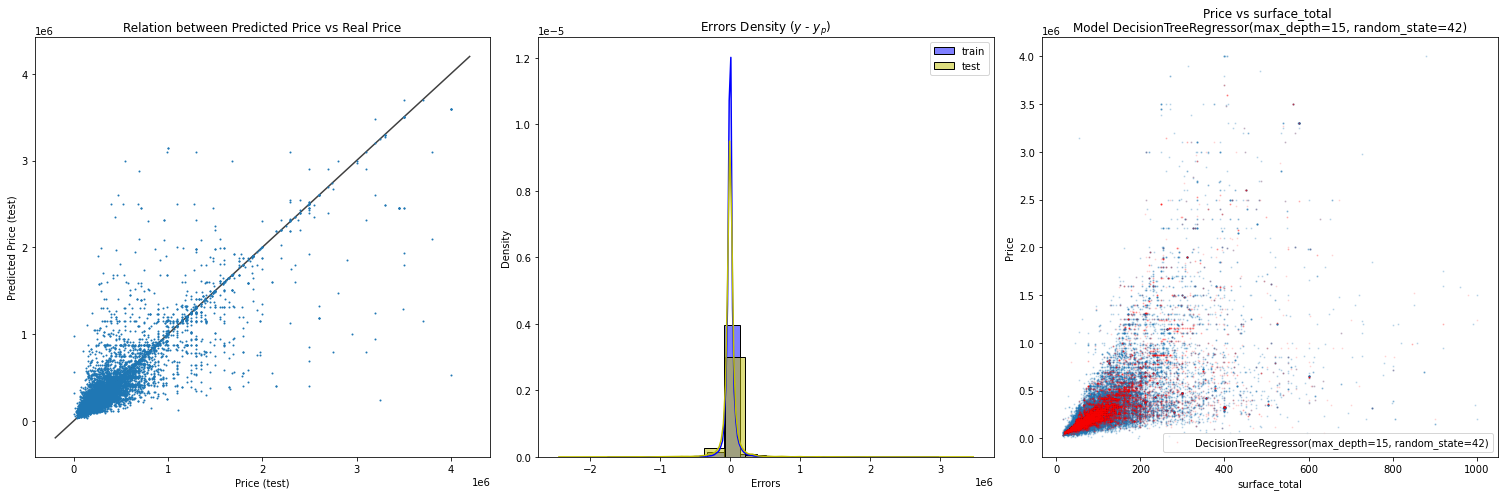

In [79]:
previous_tree = DecisionTreeRegressor(max_depth = 15, random_state=42)

models_evaluation['Decision Tree - Previous'] = build_model(previous_tree, X_prev, y_prev, show_plots = True, feature_compare = "surface_total")

**In the last project, we can see that the errors are distribuited nearly to 0, also there are errors most than 100k when we compare how behave with the surface_total the regressor works well except for houses that cost most or less than the average.**

In [80]:
results_comparation(models_evaluation, 'Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                            Model evaluation prediction of Price                            |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
+--------------------------+---------------+-----------------------+---------+---+-----------+


Now we are going to model with the current 'X' and 'y' values (This values come from the cleaning, the imputation and the PCA analysis)

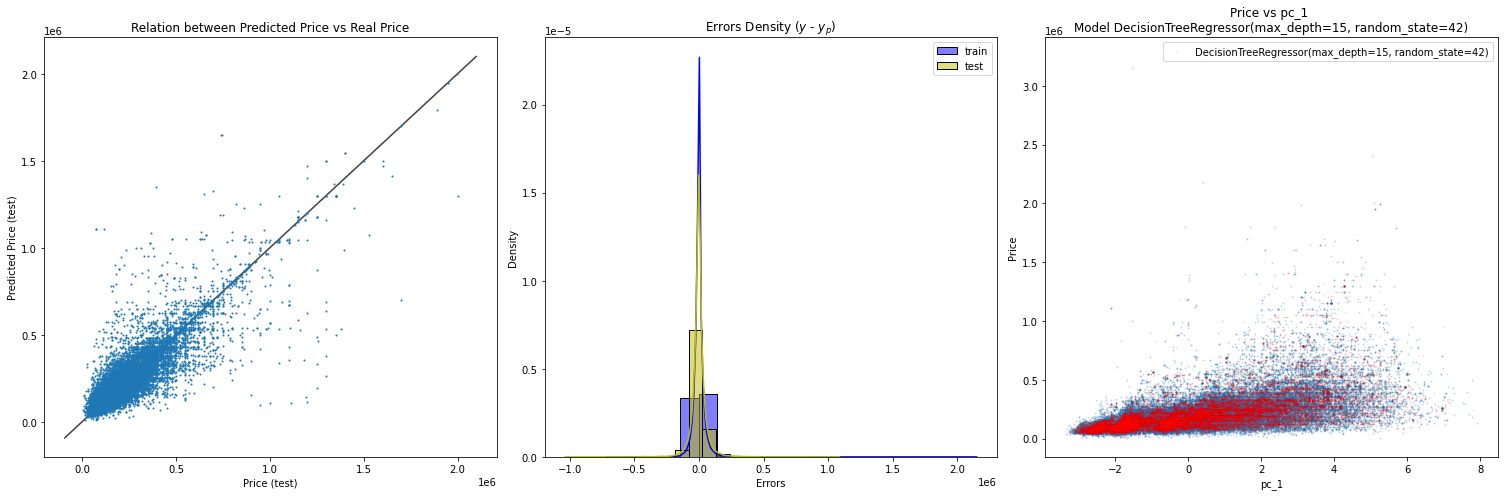

Log Price


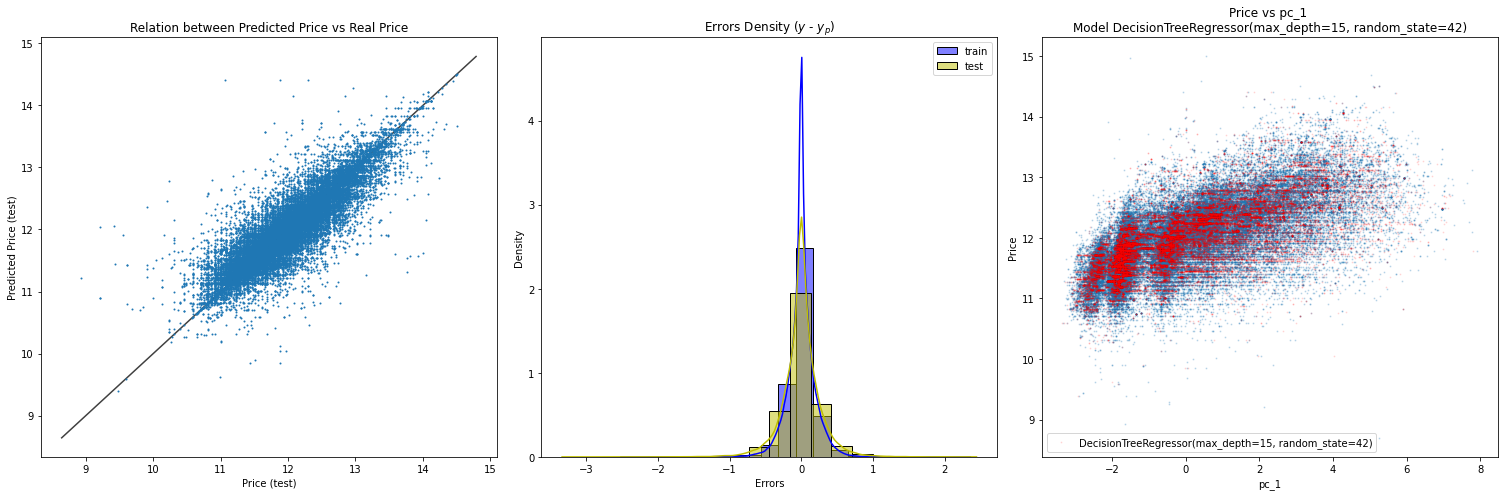

In [81]:
previous_tree = DecisionTreeRegressor(max_depth = 15, random_state=42)

models_evaluation['Decision Tree - OurData'] = build_model(previous_tree, X, y, show_plots = True)
print("Log Price")
models_evaluationlog['Decision Tree - Ourdata'] = build_model(previous_tree, X, y_log, show_plots = True)


**From the previous 3 graphs we can see that the regression tree with the optimized hyperparameters of the previous project (max_depth = 15) improves if we compare the error density because of the errors tend more to 0 whit the dataset transform and worked in this notebook is used. When applying the natural logarithm to the price, the decisions that the tree is making to predict the price are seen with better resolution.**

**The errors are located in all the range of the principal component 1**

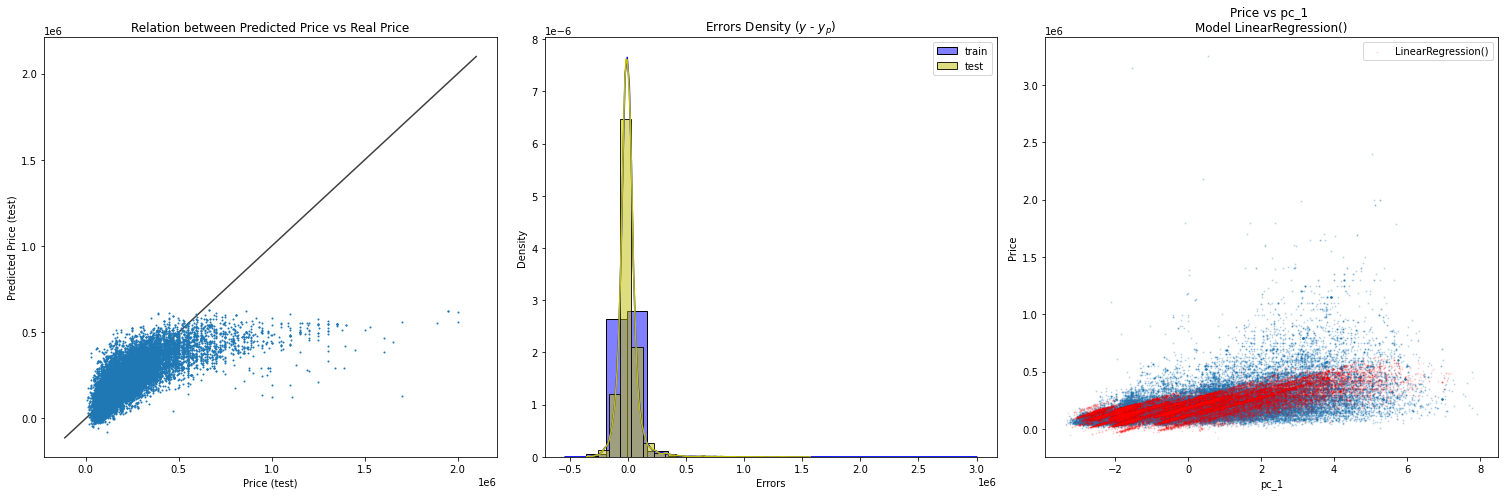

Log Price


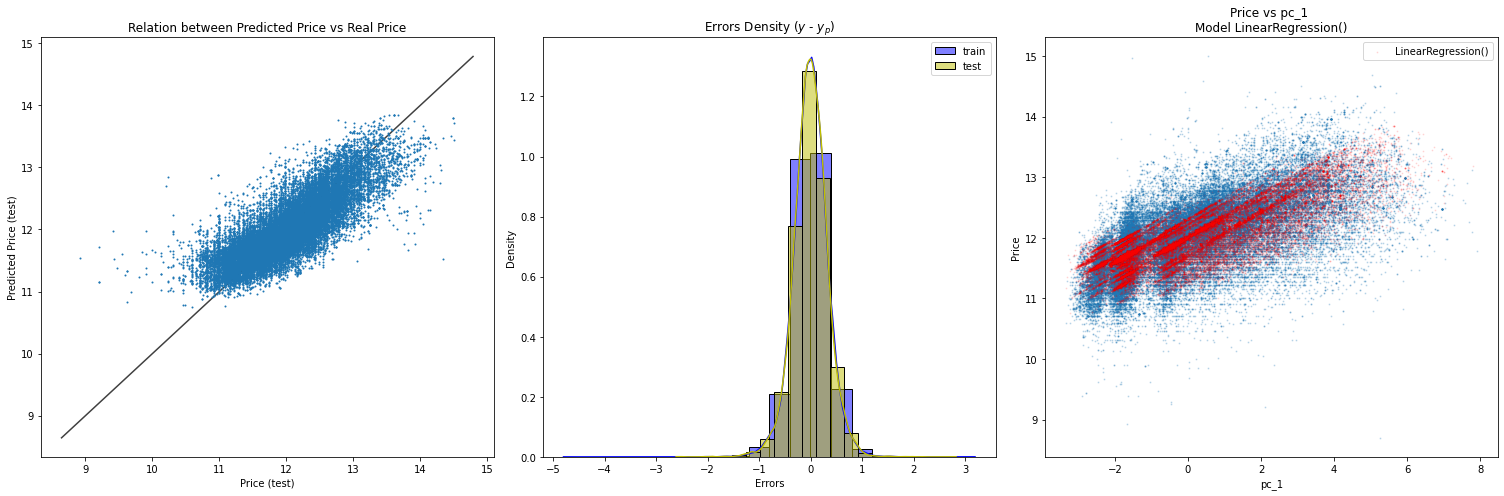

In [82]:
linear = LinearRegression()

models_evaluation['Linear Regression'] = build_model(linear, X, y, show_plots = True)
print("Log Price")
models_evaluationlog['Linear Regression Log'] = build_model(linear, X, y_log, show_plots = True)

**With linear regression is evident how the model construct the lines through the principal component 1, in this case the erros are bigger whether compare with the others models but also is a good generalation of the price predicted. With this model obtain a benchmark to improve with the advanced models, something that is remarkable is that works worse than the decision tree regressor from the first project.** 

In [83]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
+--------------------------+---------------+-----------------------+---------+---+-----------+


Analysing the models created with the current/transformed data (12 PCA features), we found an increase of 1% in the coefficient of determination. This little increase in the precision of the model could mean a lot of money depending on the business. But in this case, we are predicting prices of properties for a specific range of dates and in the real world we would need to forecast that prediction using timeseries models. So in this specific case the previous decision tree model achieve really good metrics considering that the data was not clean deeply. 

The linear regression, or the simplest model in this case had a difference against the best model of 0.176. In this case it is considerable the difference. 

In [84]:
results_comparation(models_evaluationlog, 'Table 2. Model evaluation prediction of Log Price')

+-------------------------------------------------------------------------------------------+
|                     Table 2. Model evaluation prediction of Log Price                     |
+-------------------------+---------------+-----------------------+---------+---+-----------+
|          Model          | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+-------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Ourdata |    0.89309    |        0.76465        | 0.00170 |   |  0.77252  |
|  Linear Regression Log  |    0.66345    |        0.66329        | 0.00442 |   |  0.66373  |
+-------------------------+---------------+-----------------------+---------+---+-----------+


Using a target variable transformed by using logarithm we obtained better results, an increase of 14% in the coefficient of determination.This is really usable because we obtained a great improvement with a fast transformation and say to us that reducing the dispersion of the data achieve better results.  

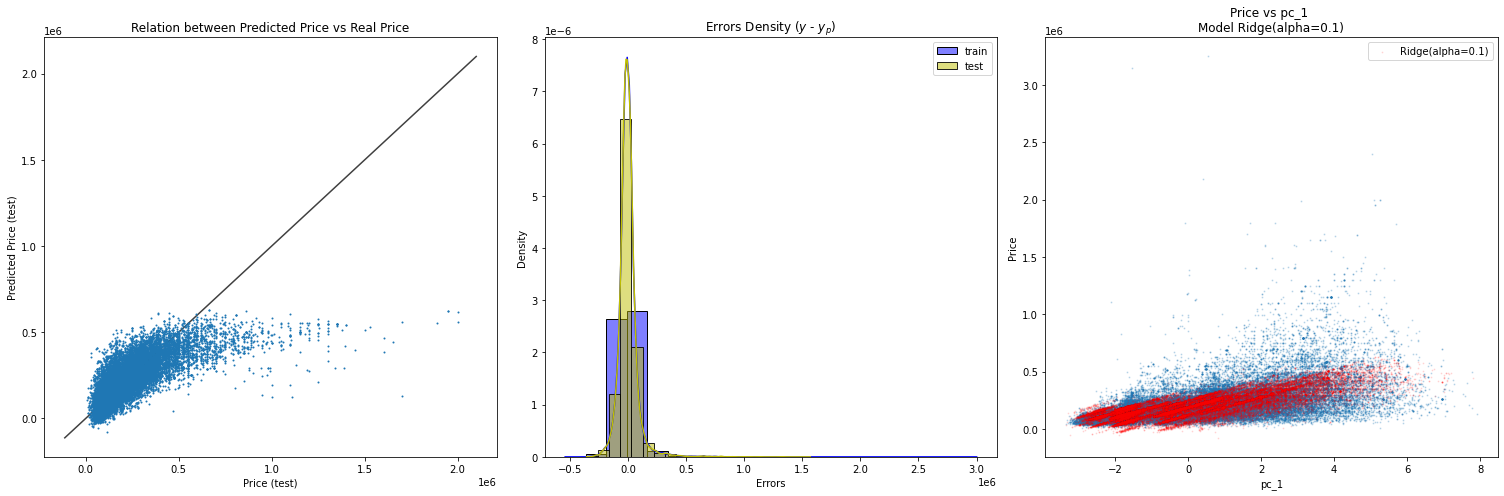

Log Price


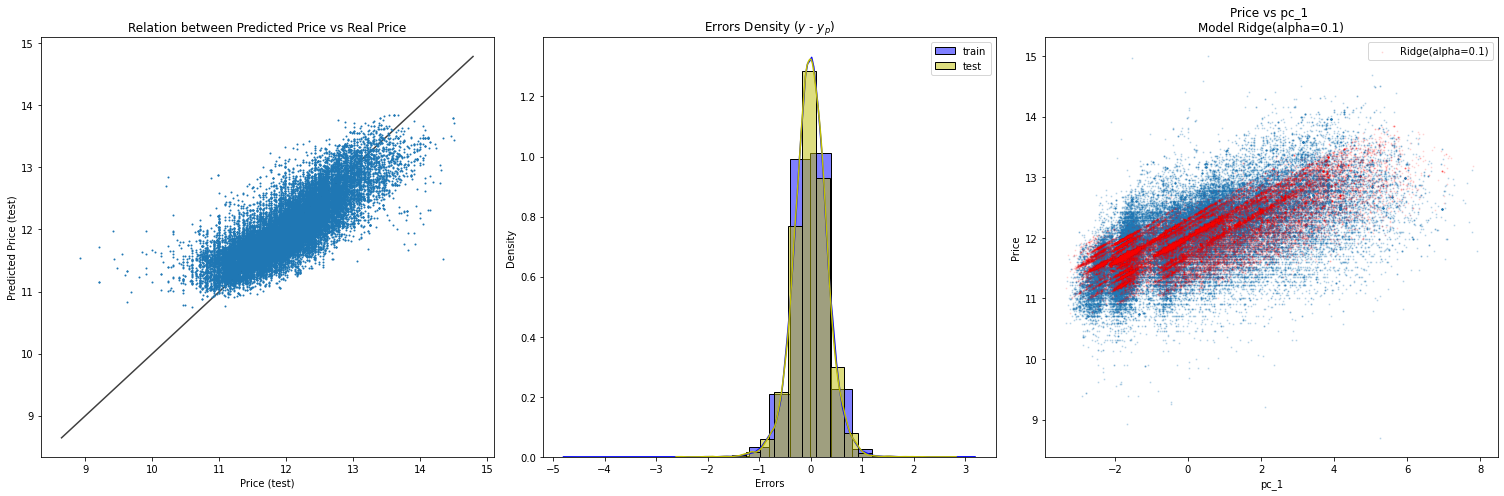

In [85]:
ridge = Ridge(alpha=0.1)

models_evaluation['Ridge Regression'] = build_model(ridge, X, y, show_plots = True)
print("Log Price")
models_evaluationlog['Ridge Regression log'] = build_model(ridge, X, y_log, show_plots = True)

We reached the cross validation R2 value of 0.75, this Ridge Regression model is comparable to the best brevious model.  

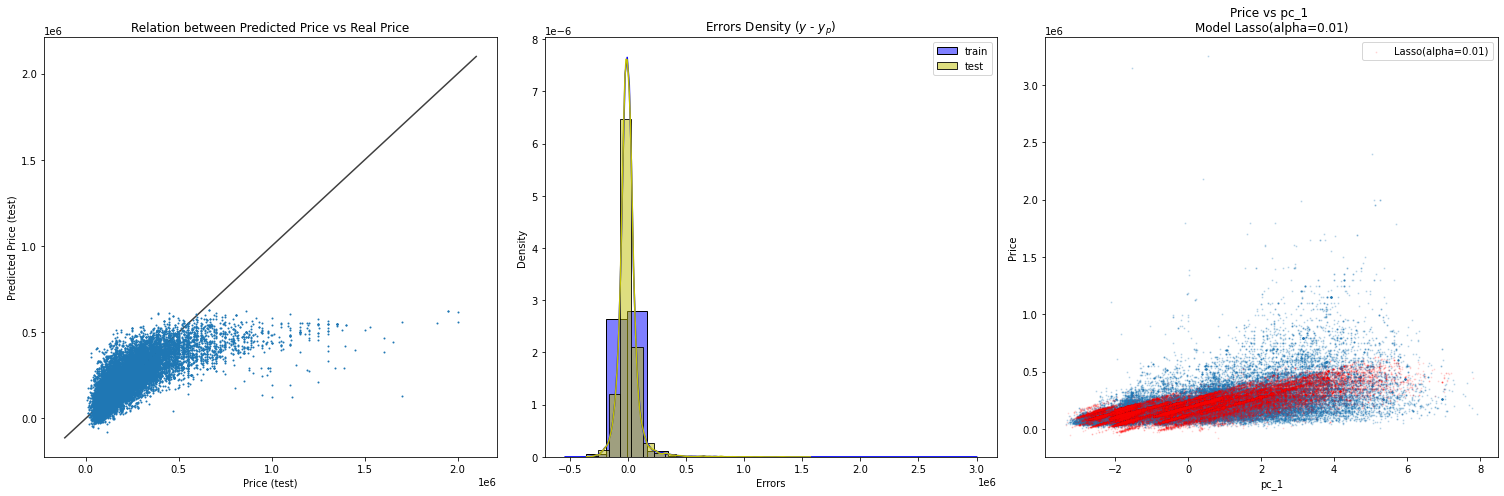

Log Price


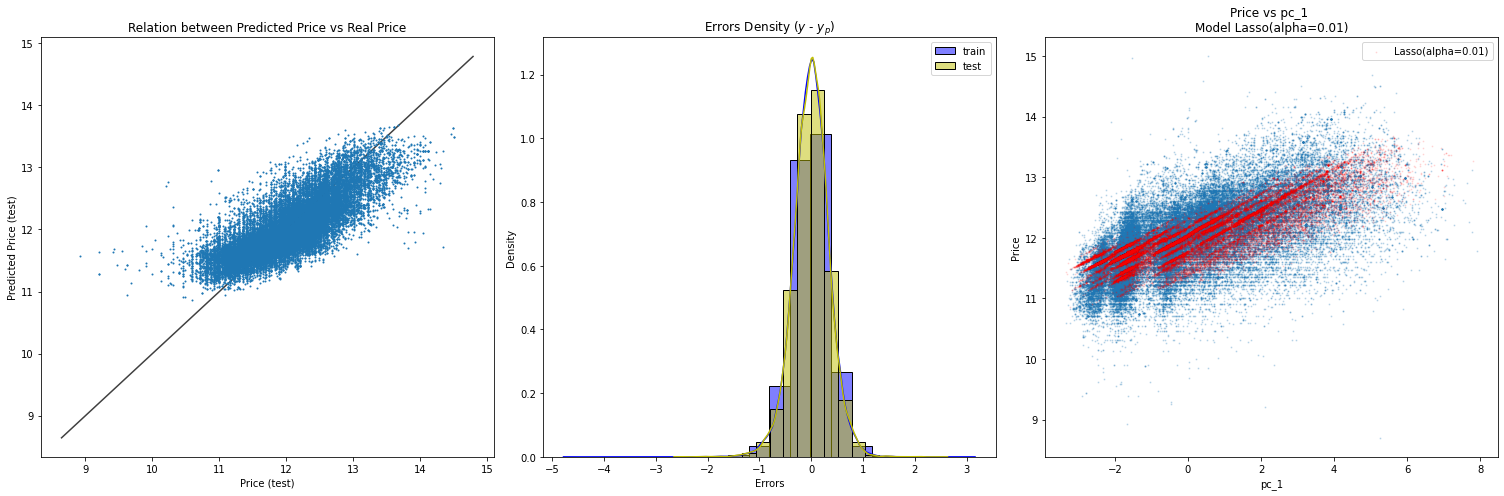

In [86]:
lasso = Lasso(alpha=0.01)

models_evaluation['Regression Lasso'] = build_model(lasso, X, y, show_plots = True)
print("Log Price")
models_evaluationlog['Regression Lasso log'] = build_model(lasso, X, y_log, show_plots = True)

In [87]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Ridge Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Regression Lasso     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
+--------------------------+---------------+------

In [88]:
results_comparation(models_evaluationlog, 'Table 2. Model evaluation prediction of Log Price')

+-------------------------------------------------------------------------------------------+
|                     Table 2. Model evaluation prediction of Log Price                     |
+-------------------------+---------------+-----------------------+---------+---+-----------+
|          Model          | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+-------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Ourdata |    0.89309    |        0.76465        | 0.00170 |   |  0.77252  |
|  Linear Regression Log  |    0.66345    |        0.66329        | 0.00442 |   |  0.66373  |
|   Ridge Regression log  |    0.66345    |        0.66329        | 0.00443 |   |  0.66373  |
|   Regression Lasso log  |    0.62602    |        0.62589        | 0.00466 |   |  0.62684  |
+-------------------------+---------------+-----------------------+---------+---+-----------+


**The linear regression, the Ridge regularization and the Lasso regularization obtained same results, only when the target variable was transformed the values changed. The linear and Ridge increased proportionally and on the other hand the Lasso dropped. This means that the feature selection applied using Lasso affected the model  only when the target variable was transformed, in other words, the penalties affected only when the price was transformed.**

<a href="#0"><font size="1">Back to contents</font></a>

### 4. Advanced Models<a id="admodeling"></a>

In this section, we are going to evaluate our data with a model advanced for this case ramdom forest and with the creation of more features we are going to improve regression lasso and ridge.

In [89]:
import gc
gc.collect()

12407

In [90]:
from sklearn.ensemble import RandomForestRegressor

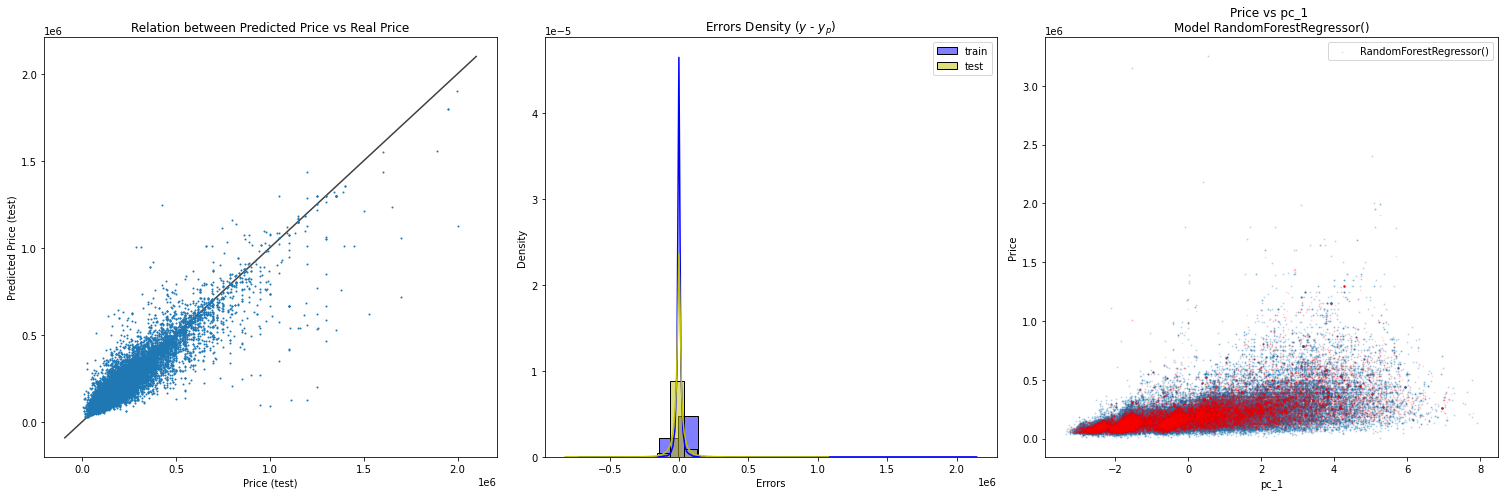

Log Price


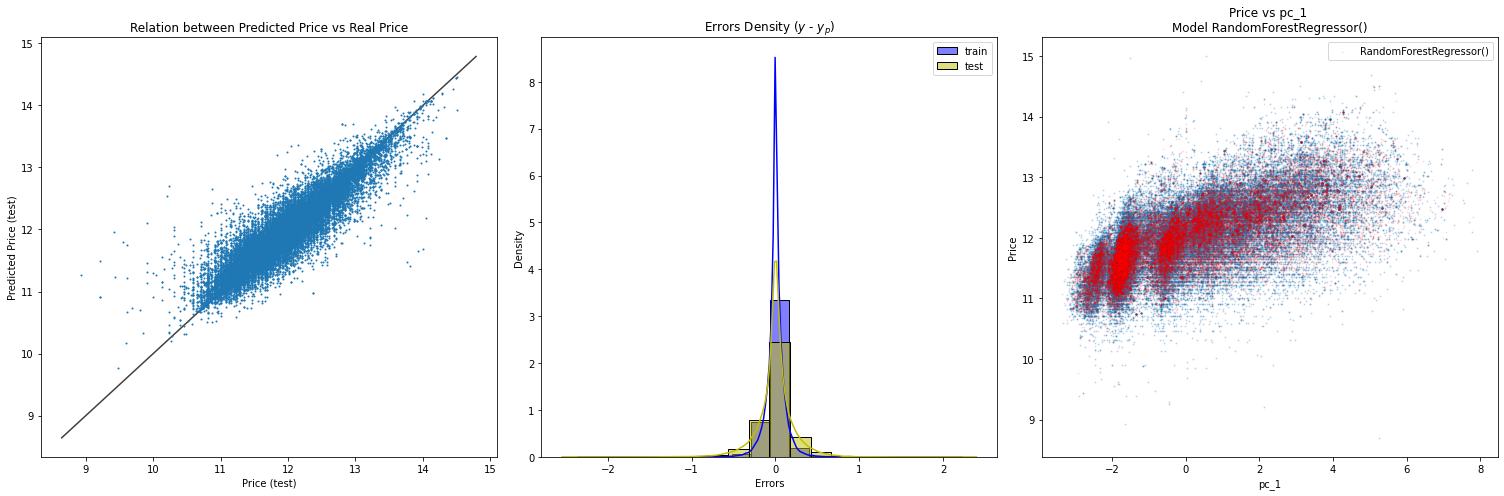

Wall time: 4min 28s


In [91]:
%%time
rf = RandomForestRegressor()

models_evaluation['Random Forest'] = build_model(rf, X, y, show_plots = True)
print("Log Price")
models_evaluationlog['Random Forest log'] = build_model(rf, X, y_log, show_plots = True)

**The errors from the random forest are very similar to the first decision tree but if we see more close, the errors are more concentrated in 0 and the error absolute dont exceed $250.000$, the zone red are bigger than the zone from the decision tree plot.**

In [92]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Ridge Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Regression Lasso     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|      Random Forest       |    0.96039    |      

In [93]:
results_comparation(models_evaluationlog, 'Table 2. Model evaluation prediction of Log Price')

+-------------------------------------------------------------------------------------------+
|                     Table 2. Model evaluation prediction of Log Price                     |
+-------------------------+---------------+-----------------------+---------+---+-----------+
|          Model          | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+-------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Ourdata |    0.89309    |        0.76465        | 0.00170 |   |  0.77252  |
|  Linear Regression Log  |    0.66345    |        0.66329        | 0.00442 |   |  0.66373  |
|   Ridge Regression log  |    0.66345    |        0.66329        | 0.00443 |   |  0.66373  |
|   Regression Lasso log  |    0.62602    |        0.62589        | 0.00466 |   |  0.62684  |
|    Random Forest log    |    0.96306    |        0.84751        | 0.00116 |   |  0.85617  |
+-------------------------+---------------+-----------------

The Random Forest obtained the best metrics in every aspect that was calculated (training, cross validation and testing), this model used all the features and created a regression model with the best possible weights for the features (up to now). Another interesting fact about this model is the capability of predict with the same precision even if the target variable was changed or not.

## Optimization of hyperparameters

### Manually Ridge

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [95]:
alphas = np.linspace(0.1, 1000, num=10)

ridge_train_scores_mean = []
ridge_train_scores_std = []
ridge_test_scores_mean = []
ridge_test_scores_std = []

for alpha in alphas:
    ridge2 = Ridge(alpha=alpha)
    ridge_scores = cross_validate(ridge2, X_train, y_train, cv=5, return_train_score=True, n_jobs = -1, scoring='r2')
    
    ridge_train_scores_mean.append(ridge_scores['train_score'].mean())
    ridge_train_scores_std.append(ridge_scores['train_score'].std())
    
    ridge_test_scores_mean.append(ridge_scores['test_score'].mean())
    ridge_test_scores_std.append(ridge_scores['test_score'].std())

ridge_train_scores_mean = np.array(ridge_train_scores_mean)
ridge_train_scores_std = np.array(ridge_train_scores_std)
ridge_test_scores_mean = np.array(ridge_test_scores_mean)
ridge_test_scores_std = np.array(ridge_test_scores_std)

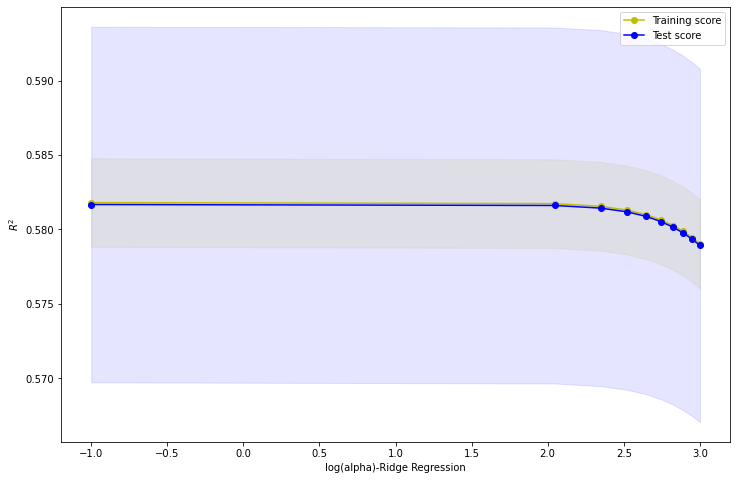

In [96]:
plt.figure(figsize=(12,8))
plt.fill_between(np.log10(alphas), ridge_train_scores_mean - ridge_train_scores_std,
                 ridge_train_scores_mean + ridge_train_scores_std, alpha=0.1,
                 color="y")
plt.fill_between(np.log10(alphas), ridge_test_scores_mean - ridge_test_scores_std,
                 ridge_test_scores_mean + ridge_test_scores_std, alpha=0.1, color="b")
plt.plot(np.log10(alphas), ridge_train_scores_mean, 'o-', color="y",
         label="Training score")
plt.plot(np.log10(alphas), ridge_test_scores_mean, 'o-', color="b",
         label="Test score")
plt.legend()
plt.ylabel('$R^2$')
plt.xlabel('log(alpha)-Ridge Regression')
plt.show()

According to graph above an alpha equals to 1 is enough to obtain the best $R^2$ possible for regression Ridge.

### Manually Lasso

In [97]:
alphas = np.linspace(0.01, 10, num=10)

lasso_train_scores_mean = []
lasso_train_scores_std = []
lasso_test_scores_mean = []
lasso_test_scores_std = []

for alpha in alphas:
    lasso2 = Lasso(alpha=alpha)
    lasso_scores = cross_validate(lasso2, X_train, y_train, cv=5, return_train_score=True, n_jobs = -1, scoring='r2')
    
    lasso_train_scores_mean.append(lasso_scores['train_score'].mean())
    lasso_train_scores_std.append(lasso_scores['train_score'].std())
    
    lasso_test_scores_mean.append(lasso_scores['test_score'].mean())
    lasso_test_scores_std.append(lasso_scores['test_score'].std())

lasso_train_scores_mean = np.array(lasso_train_scores_mean)
lasso_train_scores_std = np.array(lasso_train_scores_std)
lasso_test_scores_mean = np.array(lasso_test_scores_mean)
lasso_test_scores_std = np.array(lasso_test_scores_std)

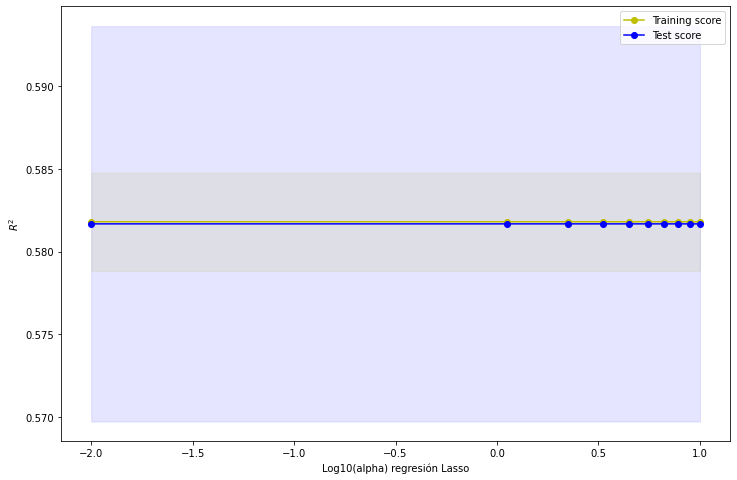

In [98]:
plt.figure(figsize=(12,8))
plt.fill_between(np.log10(alphas), lasso_train_scores_mean - lasso_train_scores_std,
                 lasso_train_scores_mean + lasso_train_scores_std, alpha=0.1,
                 color="y")
plt.fill_between(np.log10(alphas), lasso_test_scores_mean - lasso_test_scores_std,
                 lasso_test_scores_mean + lasso_test_scores_std, alpha=0.1, color="b")
plt.plot(np.log10(alphas), lasso_train_scores_mean, 'o-', color="y",
         label="Training score")
plt.plot(np.log10(alphas), lasso_test_scores_mean, 'o-', color="b",
         label="Test score")
plt.legend()
plt.ylabel('$R^2$')
plt.xlabel('Log10(alpha) regresión Lasso')
plt.show()

In Lasso an alpha equal to 1, is the best parameter. But now we are going to see, what happen when we create more features.

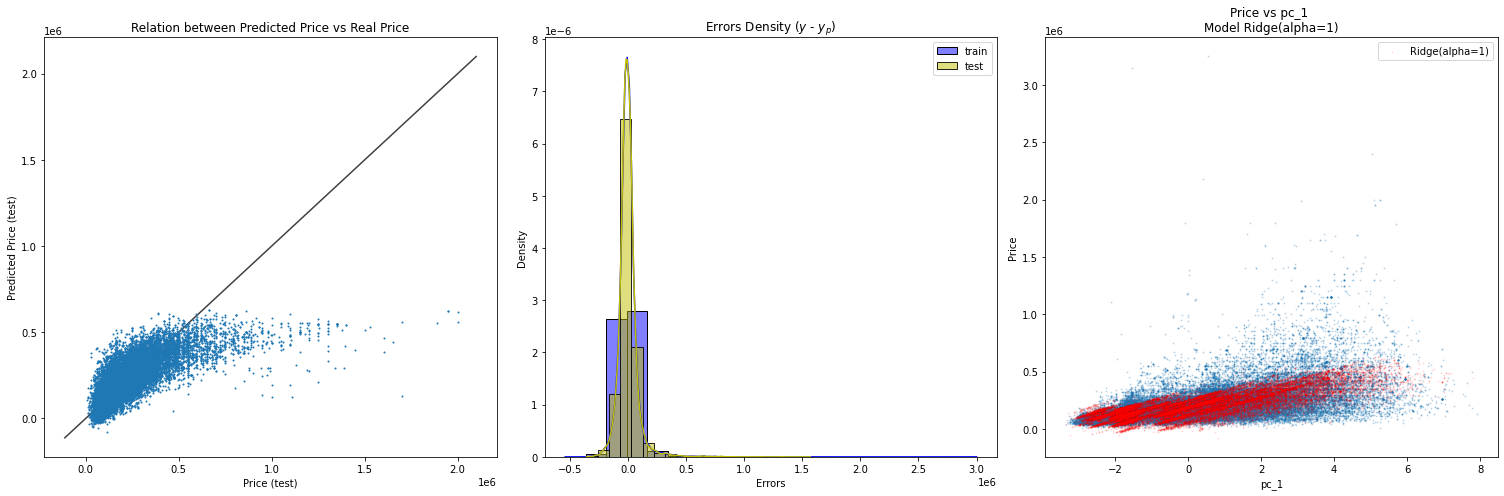

In [99]:
ridge = Ridge(alpha=1)

models_evaluation['Ridge Regression Opt'] = build_model(ridge, X, y, show_plots = True)

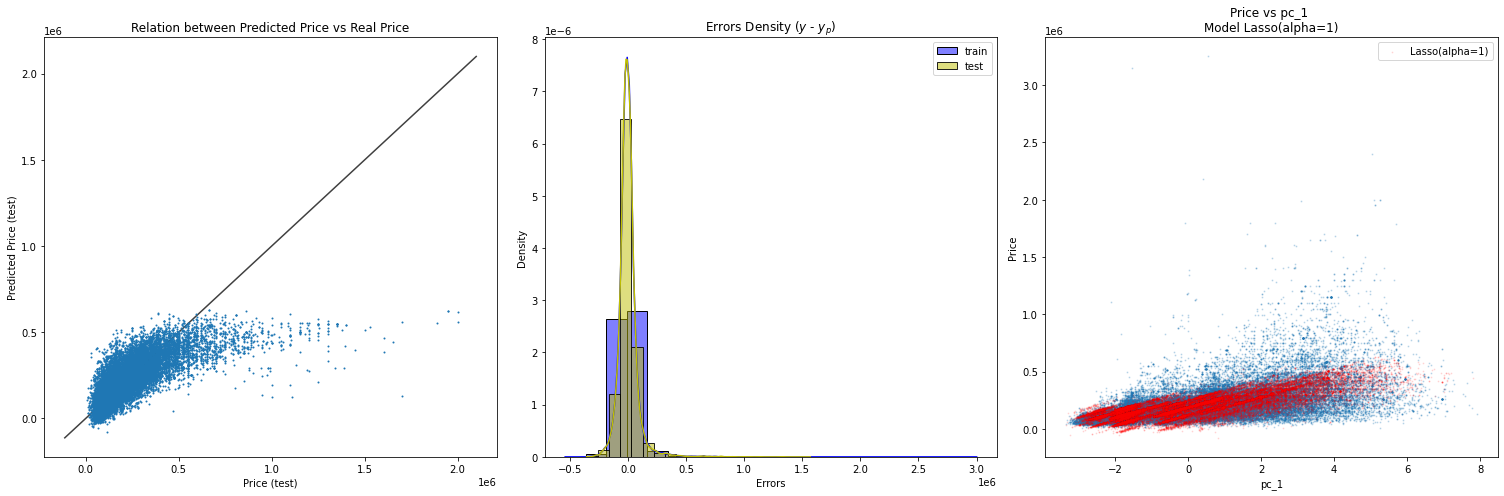

In [100]:
lasso = Lasso(alpha=1)

models_evaluation['Regression Lasso Opt'] = build_model(lasso, X, y, show_plots = True)

**The errors obtained are the same with the first linear models.**

In [101]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Ridge Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Regression Lasso     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|      Random Forest       |    0.96039    |      

In [102]:
c = 0
features = ['pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_7', 'pc_8', 'pc_9', 'pc_14', 'pc_17','pc_20', 'pc_22']
for coeficient in ridge.coef_:
    print(f"Coeficient {features[c]}: {coeficient}" )
    c+=1

Coeficient pc_1: 43040.71136918497
Coeficient pc_2: 49278.40918827239
Coeficient pc_3: -20145.262161508395
Coeficient pc_4: -55149.59200712592
Coeficient pc_5: -59917.90283047899
Coeficient pc_7: -26572.283410265565
Coeficient pc_8: 21332.81444334191
Coeficient pc_9: 44521.63780181302
Coeficient pc_14: 44860.24215672147
Coeficient pc_17: 32845.80595173083
Coeficient pc_20: -55933.25571126166
Coeficient pc_22: 74528.49113012744


In [103]:
c = 0
for coeficient in lasso.coef_:
    print(f"Coeficient {features[c]}: {coeficient}" )
    c+=1

Coeficient pc_1: 43040.584458153535
Coeficient pc_2: 49277.73976292047
Coeficient pc_3: -20143.79426496479
Coeficient pc_4: -55148.46193297365
Coeficient pc_5: -59916.31255765793
Coeficient pc_7: -26567.153324831528
Coeficient pc_8: 21326.03809632589
Coeficient pc_9: 44516.20007153301
Coeficient pc_14: 44850.31192050148
Coeficient pc_17: 32827.25017799161
Coeficient pc_20: -55919.02798159059
Coeficient pc_22: 74522.78079184274


**The ridge and lasso regressions are behave very similar with the 12 chosen principal components, their coefficients are very similar and in absolute values. It is remarkable how the pc_22 coefficients is the highest value and it is understandable because in theory it is one of the features that is least correlated with price, this trend is lost when we observe the lowest coefficients corresponding to pc_3 and pc_8, because we expected that the features with a coefficient closest to 1 would be pc_1 and pc_2 because they are the most correlated to price.***

In [104]:
gc.collect()

12328

In [105]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2, include_bias=False) 
X_trainnew = poly.fit_transform(X_train)
X_poly = poly.fit_transform(X)

In [106]:
alphas = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1]

ridge_train_scores_mean = []
ridge_train_scores_std = []
ridge_test_scores_mean = []
ridge_test_scores_std = []

for alpha in alphas:
    ridge2 = Ridge(alpha=alpha)
    ridge_scores = cross_validate(ridge2, X_trainnew, y_train, cv=5, return_train_score=True, n_jobs = -1, scoring='r2')
    
    ridge_train_scores_mean.append(ridge_scores['train_score'].mean())
    ridge_train_scores_std.append(ridge_scores['train_score'].std())
    
    ridge_test_scores_mean.append(ridge_scores['test_score'].mean())
    ridge_test_scores_std.append(ridge_scores['test_score'].std())

ridge_train_scores_mean = np.array(ridge_train_scores_mean)
ridge_train_scores_std = np.array(ridge_train_scores_std)
ridge_test_scores_mean = np.array(ridge_test_scores_mean)
ridge_test_scores_std = np.array(ridge_test_scores_std)

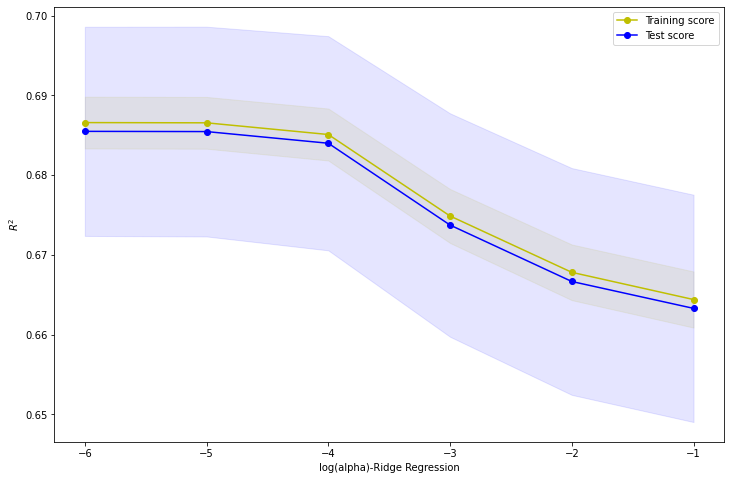

In [107]:
plt.figure(figsize=(12,8))
plt.fill_between(np.log10(alphas), ridge_train_scores_mean - ridge_train_scores_std,
                 ridge_train_scores_mean + ridge_train_scores_std, alpha=0.1,
                 color="y")
plt.fill_between(np.log10(alphas), ridge_test_scores_mean - ridge_test_scores_std,
                 ridge_test_scores_mean + ridge_test_scores_std, alpha=0.1, color="b")
plt.plot(np.log10(alphas), ridge_train_scores_mean, 'o-', color="y",
         label="Training score")
plt.plot(np.log10(alphas), ridge_test_scores_mean, 'o-', color="b",
         label="Test score")
plt.legend()
plt.ylabel('$R^2$')
plt.xlabel('log(alpha)-Ridge Regression')
plt.show()

The best $alpha = 0.00001$ or as we can see $log(alpha) = -4$

In [108]:
alphas = np.linspace(0.01, 1, num=5)

lasso_train_scores_mean = []
lasso_train_scores_std = []
lasso_test_scores_mean = []
lasso_test_scores_std = []

for alpha in alphas:
    lasso2 = Lasso(alpha=alpha)
    lasso_scores = cross_validate(lasso2, X_trainnew, y_train, cv=5, return_train_score=True, n_jobs = -1, scoring='r2')
    
    lasso_train_scores_mean.append(lasso_scores['train_score'].mean())
    lasso_train_scores_std.append(lasso_scores['train_score'].std())
    
    lasso_test_scores_mean.append(lasso_scores['test_score'].mean())
    lasso_test_scores_std.append(lasso_scores['test_score'].std())

lasso_train_scores_mean = np.array(lasso_train_scores_mean)
lasso_train_scores_std = np.array(lasso_train_scores_std)
lasso_test_scores_mean = np.array(lasso_test_scores_mean)
lasso_test_scores_std = np.array(lasso_test_scores_std)

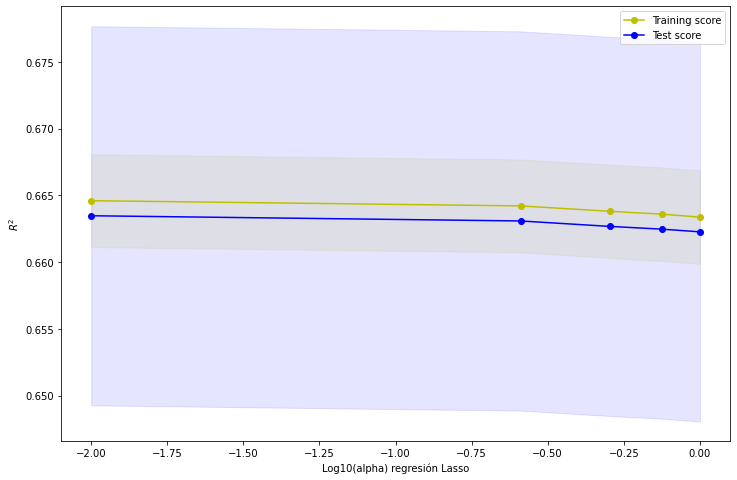

In [109]:
plt.figure(figsize=(12,8))
plt.fill_between(np.log10(alphas), lasso_train_scores_mean - lasso_train_scores_std,
                 lasso_train_scores_mean + lasso_train_scores_std, alpha=0.1,
                 color="y")
plt.fill_between(np.log10(alphas), lasso_test_scores_mean - lasso_test_scores_std,
                 lasso_test_scores_mean + lasso_test_scores_std, alpha=0.1, color="b")
plt.plot(np.log10(alphas), lasso_train_scores_mean, 'o-', color="y",
         label="Training score")
plt.plot(np.log10(alphas), lasso_test_scores_mean, 'o-', color="b",
         label="Test score")
plt.legend()
plt.ylabel('$R^2$')
plt.xlabel('Log10(alpha) regresión Lasso')
plt.show()

Polynomial Feature


C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py:52: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


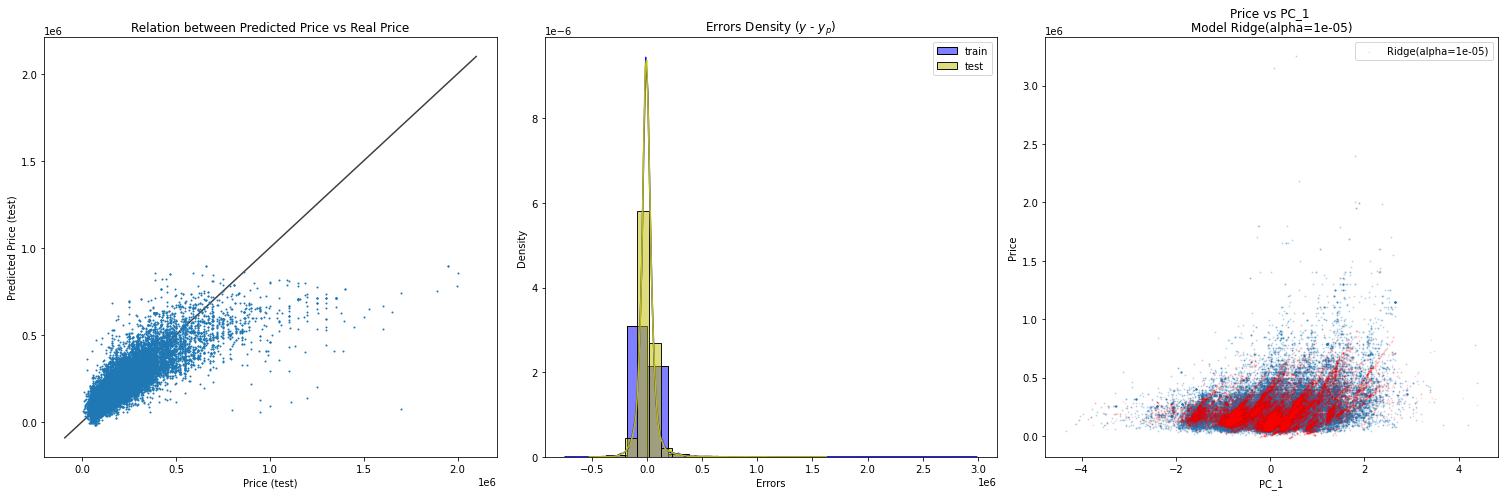

In [110]:
ridge = Ridge(alpha=0.00001)

models_evaluation['Ridge Regression PF'] = build_model(ridge, X_poly, y, show_plots = True)

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:532: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 199098145741201.0, tolerance: 157731596748.88834
  positive)


Polynomial Feature


C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py:52: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


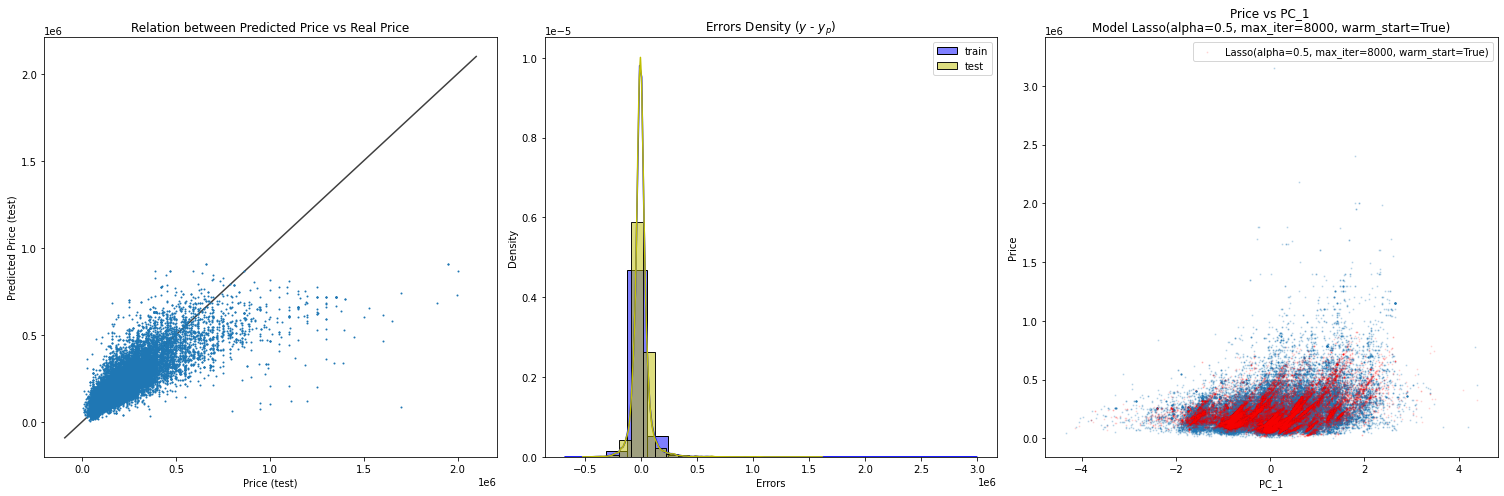

Wall time: 1min 40s


In [111]:
%%time
lasso = Lasso(alpha=0.5, max_iter=10000, warm_start=True)

models_evaluation['Regression Lasso PF'] = build_model(lasso, X_poly, y, show_plots = True)

**Create new features with polynomial features allow the model improves th lines genrated generalize more the behavior of the price and the principal components. If we compare with linear model without polynomial features the lines are more verticals and with a curve similar to a curve of a cuadratict function and catch better the price predicted.**

In [112]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Ridge Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Regression Lasso     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|      Random Forest       |    0.96039    |      

### Random Search

In [113]:
from sklearn.model_selection import RandomizedSearchCV

In [114]:
gc.collect()

30995

In [115]:
%%time
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

hp_candidates = [{'n_estimators': np.arange(50, 201, 10),
                  'max_depth':np.arange(10, 30, 1)}]

rs = RandomizedSearchCV(estimator=rf, param_distributions=hp_candidates, n_iter=15,
                    scoring='r2', cv=5, random_state=42)

rs.fit(X_train, y_train)

print(rs.best_score_)
print(rs.best_estimator_)
print(rs.best_params_)

0.8254979740438593
RandomForestRegressor(max_depth=24, n_estimators=110)
{'n_estimators': 110, 'max_depth': 24}
Wall time: 1h 21min 36s


In [130]:
%%time
rf = RandomForestRegressor(n_estimators= 110, max_depth= 24)

models_evaluation['Random Forest RS'] = build_model(rf, X, y)

Wall time: 2min 27s


<BarContainer object of 12 artists>

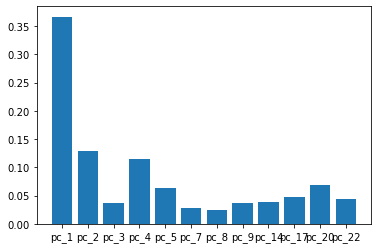

In [131]:
features = ['pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_7', 'pc_8', 'pc_9', 'pc_14', 'pc_17','pc_20', 'pc_22']

plt.bar(features, rf.feature_importances_)

In [125]:
gc.collect()

32

In [128]:
%%time
rflog = RandomForestRegressor(n_estimators= 110, max_depth= 24)

models_evaluationlog['Random Forest RS (log)'] = build_model(rflog, X, y_log)

Wall time: 2min 26s


<BarContainer object of 12 artists>

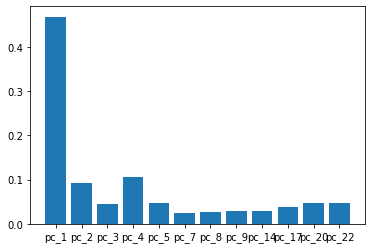

In [129]:
plt.bar(features, rflog.feature_importances_)

<a href="#0"><font size="1">Back to contents</font></a>

### 5. Conclusions<a id="con"></a>

* Comparisson between project 1 and 2, cleaning: 

The results of the models run by the second project are a clear expression that a good model needs good data. And the data cleaning that was done in the second project it is better by far. The second cleaning process and data manipulation was done by the following steps:

Firstable this time we did an analysis of the missing data and found between what ranges the data was missing the most. The answer was that the missing values in covered surface column were more common for departments with low numbers of rooms, bathrooms, lower price and lower total surface. The same analysis can be applied for the total surface column and the number of bathrooms.

After that we created a model of imputation for the missing data using K-nearest neighbors, due to the fact that the largest amount of missing data was between the same range of features. Then we did an outlier analysis using three different methods and selecting by the one that created features more correlated to the target variable, the price. 

Then, we did encoding of the data, because this time we wanted to use the information that was embedded in the characters. We ended up with a lot of features (104) and that is the reason why we use Principal Component Analysis in order to transform the data to lower the dimensionality of the dataset.

We found that with only 27 principal components we can represent the 95% of the data. After that we calculated the correlation between the principal components features to the target. We used the principal components with high correlation and selected 12 components for data modeling.

**Analysing the models created with the current/transformed data (12 PCA features), we found an increase of 1% in the coefficient of determination. This little increase in the precision of the model could mean a lot of money depending on the business.** But in this case, we are predicting prices of properties for a specific range of dates and in the real world we would need to forecast that prediction using timeseries models. So in this specific case the previous decision tree model achieve really good metrics considering that the data was not clean deeply. 

The linear regression, or the simplest model in this case had a difference against the best model of 0.176. In this case it is considerable the difference.  

* Comparisson between project 1 and 2, modeling: 

We use the best model that was trained in the last project and used it as benchmark in order to evaluate the performance of the models that were trained with better processed and cleaned data.

The results were saved in a table that allows to compare between past models and behaviour in trainind and testing:

In [132]:
results_comparation(models_evaluation, 'Table 1. Model evaluation prediction of Price')

+--------------------------------------------------------------------------------------------+
|                       Table 1. Model evaluation prediction of Price                        |
+--------------------------+---------------+-----------------------+---------+---+-----------+
|          Model           | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+--------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Previous |    0.92628    |        0.72236        | 0.01725 |   |  0.76774  |
| Decision Tree - OurData  |    0.91139    |        0.72268        | 0.02541 |   |  0.76157  |
|    Linear Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Ridge Regression     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|     Regression Lasso     |    0.58179    |        0.58168        | 0.01195 |   |  0.58893  |
|      Random Forest       |    0.96039    |      

The next table has the same comparisson but using the logarithm of the price:

In [133]:
results_comparation(models_evaluationlog, 'Table 2. Model evaluation prediction of Log Price')

+-------------------------------------------------------------------------------------------+
|                     Table 2. Model evaluation prediction of Log Price                     |
+-------------------------+---------------+-----------------------+---------+---+-----------+
|          Model          | R2 (Training) | R2 (Cross Validation) |  (+/-)  |   | R2 (Test) |
+-------------------------+---------------+-----------------------+---------+---+-----------+
| Decision Tree - Ourdata |    0.89309    |        0.76465        | 0.00170 |   |  0.77252  |
|  Linear Regression Log  |    0.66345    |        0.66329        | 0.00442 |   |  0.66373  |
|   Ridge Regression log  |    0.66345    |        0.66329        | 0.00443 |   |  0.66373  |
|   Regression Lasso log  |    0.62602    |        0.62589        | 0.00466 |   |  0.62684  |
|    Random Forest log    |    0.96306    |        0.84751        | 0.00116 |   |  0.85617  |
|  Random Forest RS (log) |    0.96043    |        0.84755  

The Random Forest obtained the best metrics in every aspect that was calculated (training, cross validation and testing), this model used all the features and created a regression model with the best possible weights for the features. Another interesting fact about this model is the capability of predict with the same precision even if the target variable was changed or not.

For the linear regression, the Ridge regularization and the Lasso regularization we obtained same results, only when the target variable was transformed the values changed. The linear and Ridge increased proportionally and on the other hand the Lasso dropped. This means that the feature selection applied using Lasso affected the model  only when the target variable was transformed, in other words, the penalties affected only when the price was transformed.

* Errors

In general the models do not predict well the behaviour of all the data, the data behaviour is spread as a cone and in their limits is hard to capture and predict. Maybe with more information, extraction more features or creation of transformed features this part of the behavior could be better predicted. 

*  Polinomial features vs regular

After adding features, we observe the same behaviour of the first graph for the Ridge regularization method but in this case the alpha needed decreased by 10000. For the model with more features we need to apply less weights or penalties in order to obtain good performing results.

With the Lasso regularization method it was harder to find a change in the behaviour, and it it practically the same the performance of the model for the 5 chosen alphas. It is important to say that when alpha is 0 , Lasso regression produces the same coefficients as a linear regression.

* Grid search

The grid search done did not improve our model performance, but the difference between with grid search and without was not that considerable. In this topic we recommend try more hyperparameter if an improvement is needed  but having a  metric of 0.86% for the testing group it is really good and it is our best model obtained for this dataset. 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a0fd2db8-738e-4114-af51-6fc0b3c1a802' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>